In [ ]:
!pip install --upgrade scikit-learn lightgbm xgboost catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.3 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.0.4
    Uninstalling xgboost-3.0.4:
      Successfully uninstalled xgboost-3.0.4
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
!pip install catboost


KeyboardInterrupt: 

In [ ]:
!pip install shap


Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001667 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


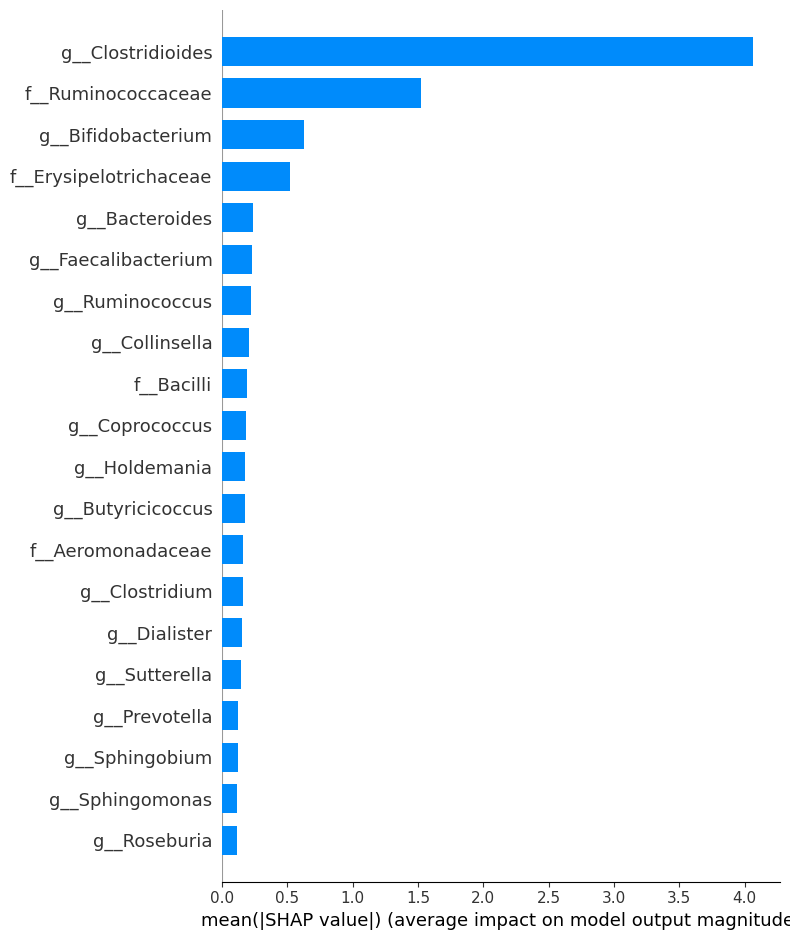

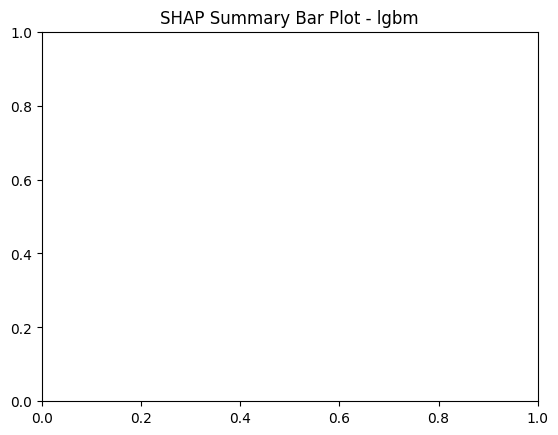

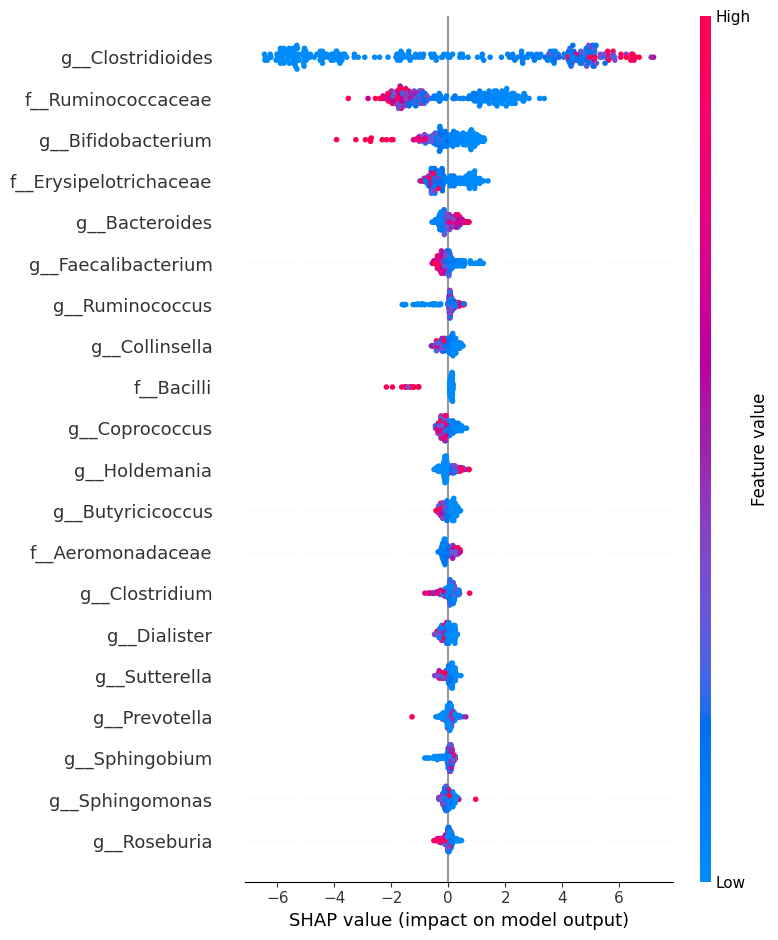

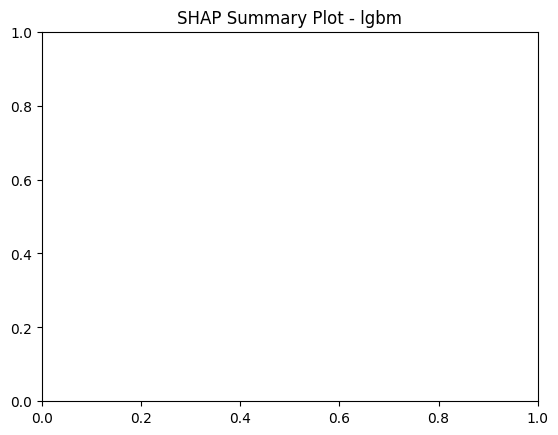

Training catboost...
Performing SHAP analysis for catboost...


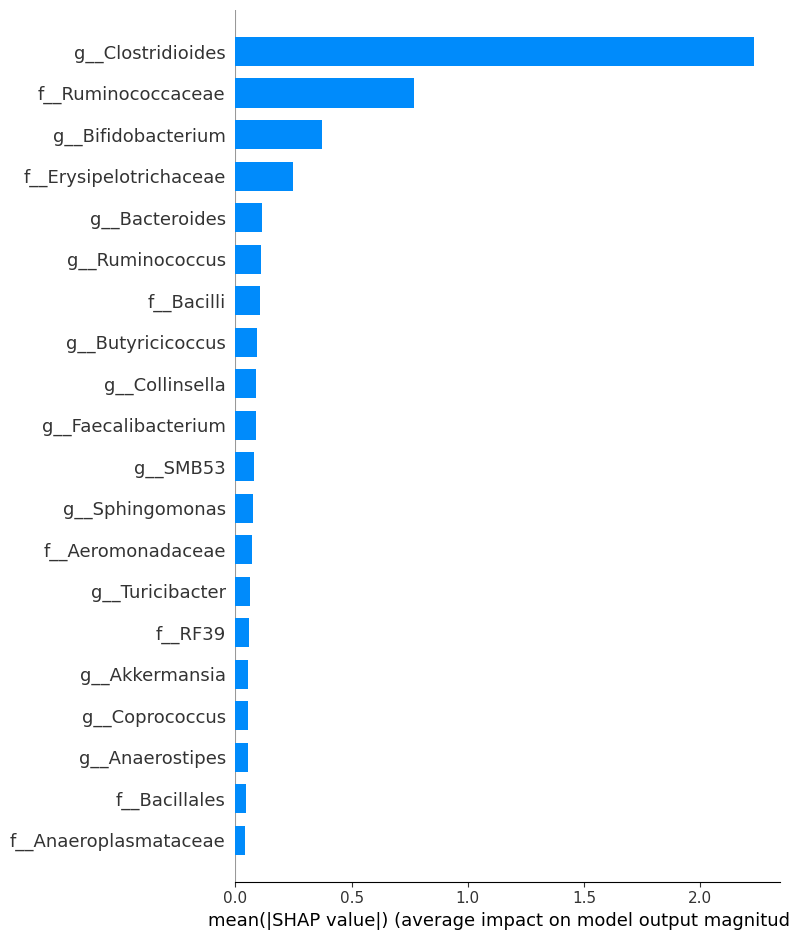

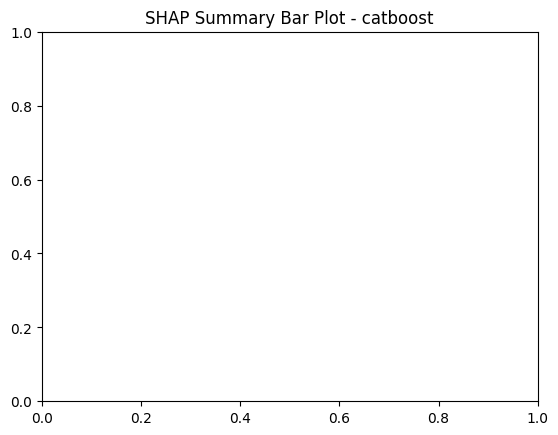

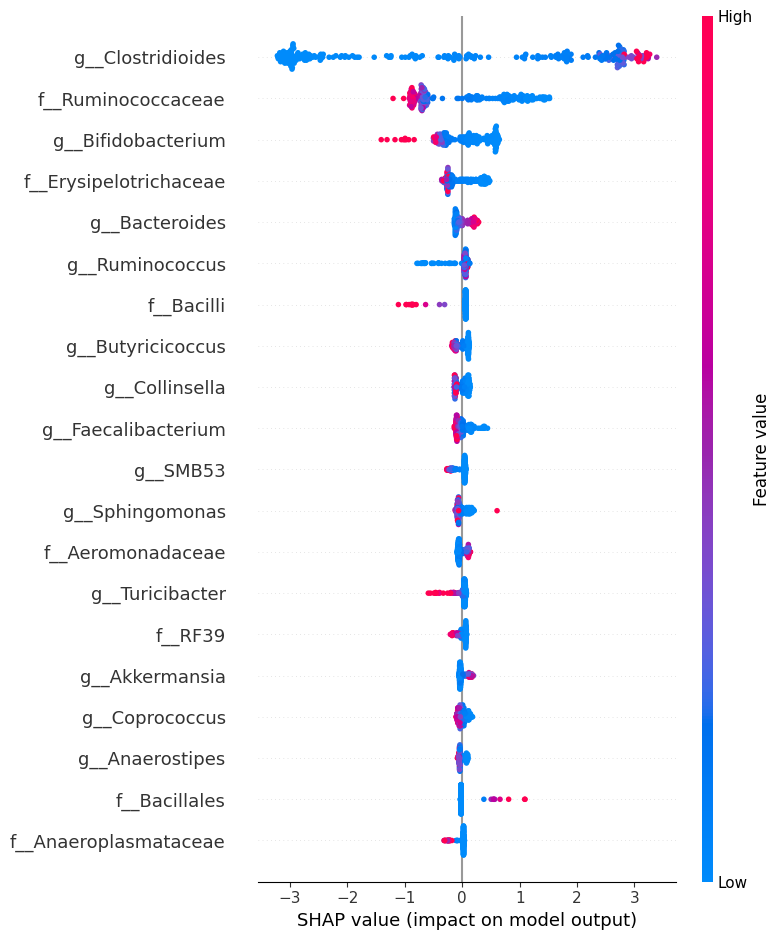

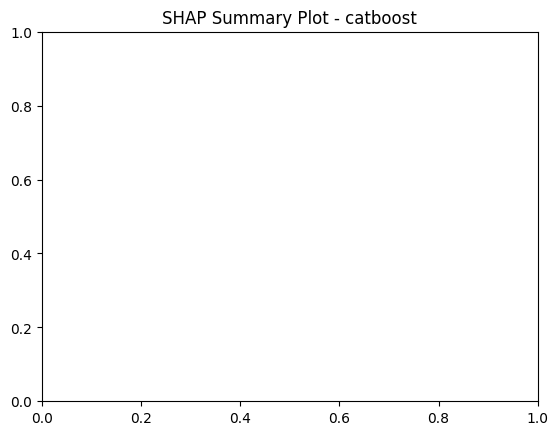

Training xgboost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:44:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:44:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:44:55] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:44:56] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [05:44:57] WARNING: /w

Performing SHAP analysis for xgboost...


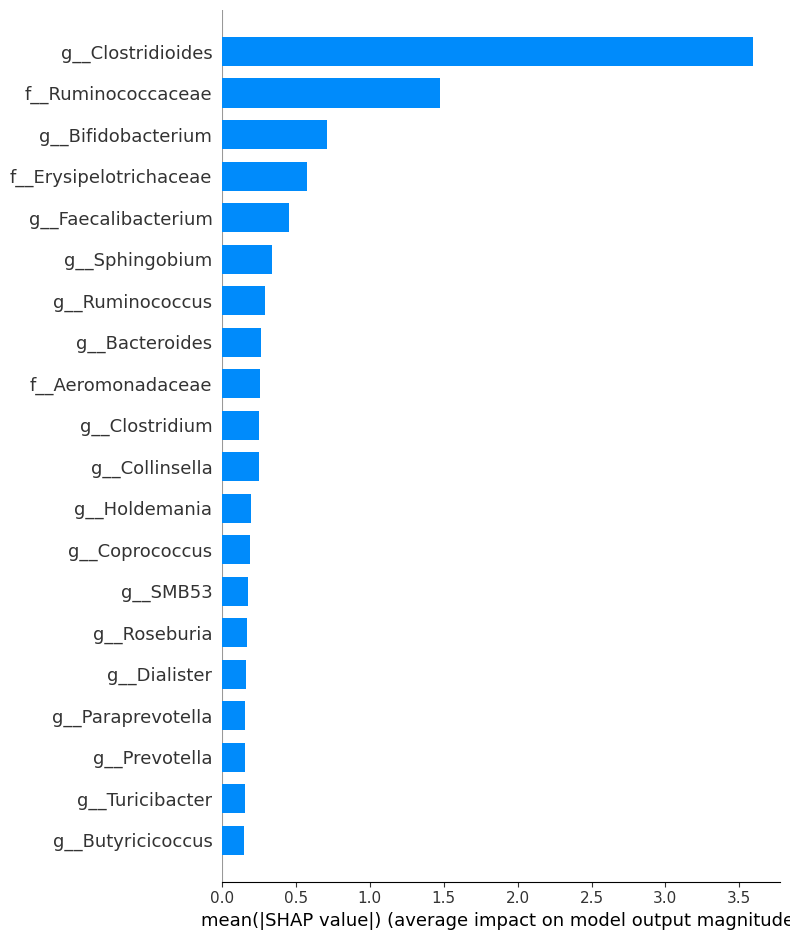

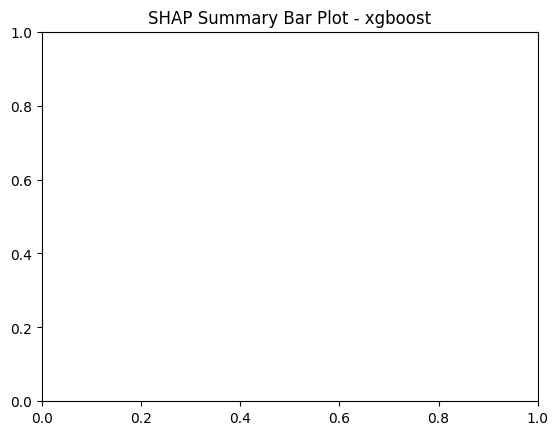

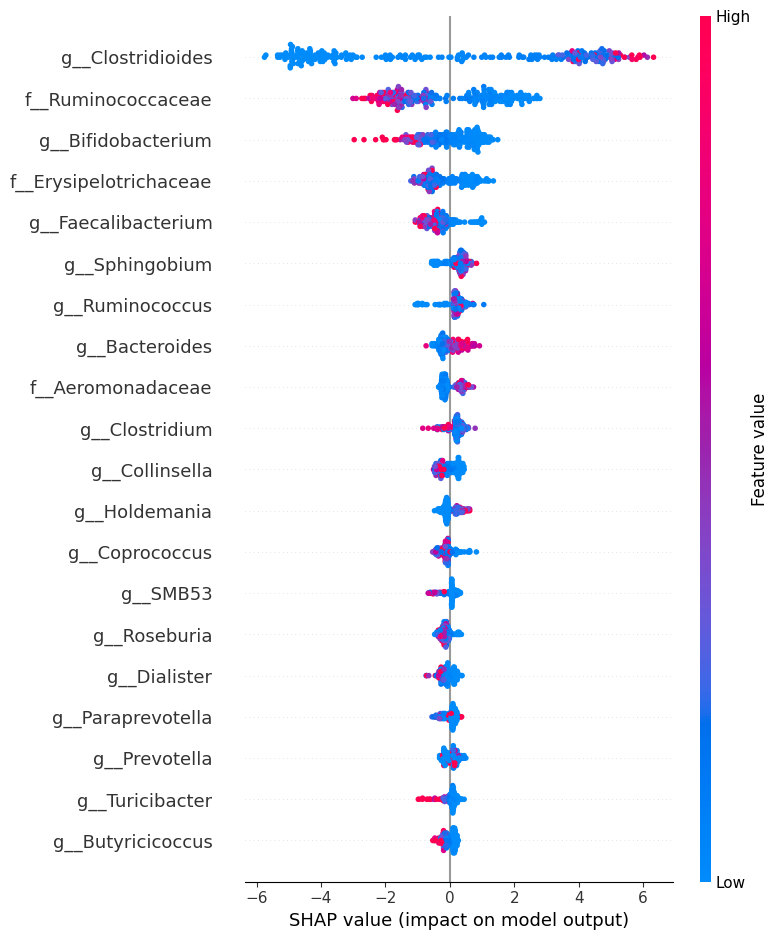

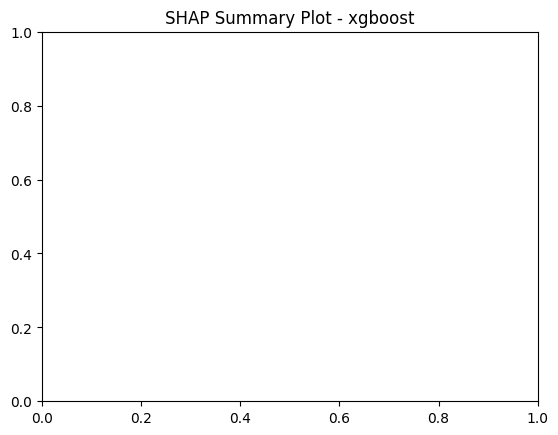

Final AUC of the blended model: 0.9745

Blended Model Performance Metrics:
Precision: 0.931
Recall (Sensitivity): 0.891
Specificity: 0.923
F1 Score: 0.910
Accuracy: 0.906
AUC: 0.975
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

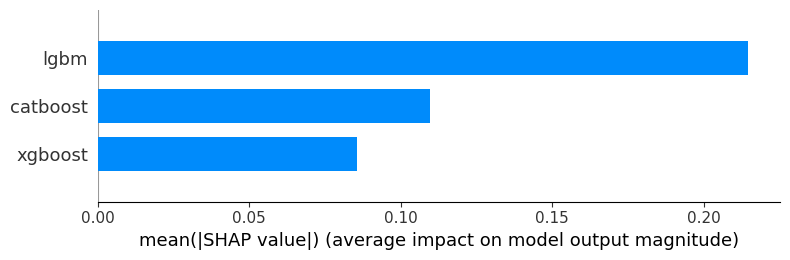

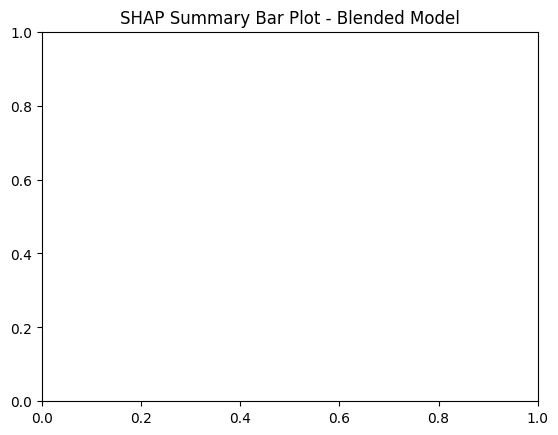

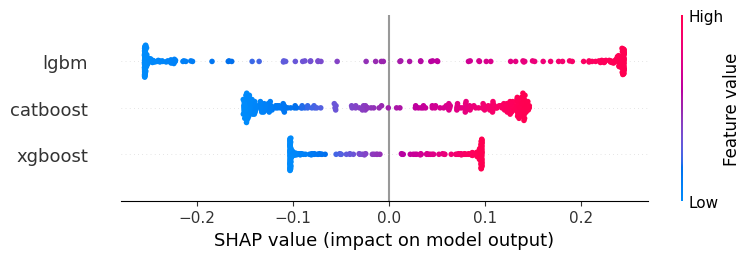

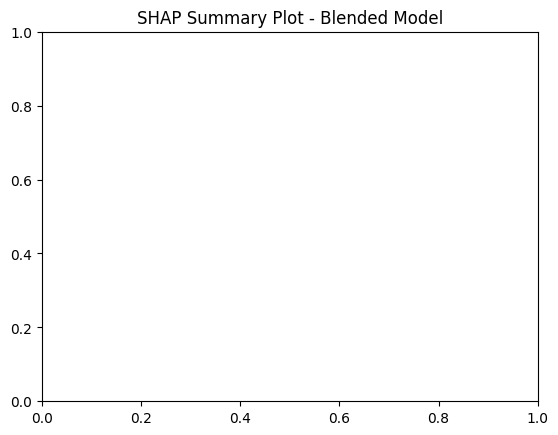

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('/content/final_input.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # SHAP Bar Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X.columns.tolist())
    plt.title(f"SHAP Summary Bar Plot - {name}")
    plt.show()

    # SHAP Beeswarm Plot (Optional, more detailed)
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())
    plt.title(f"SHAP Summary Plot - {name}")
    plt.show()

# Blending: Assign weights to the base models
weights = [0.5, 0.3, 0.2]  # LGBM: 50%, CatBoost: 30%, XGBoost: 20%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Bar Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", feature_names=list(base_models.keys()))
plt.title("SHAP Summary Bar Plot - Blended Model")
plt.show()

# SHAP Beeswarm Plot for Blended Model (Optional)
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))
plt.title("SHAP Summary Plot - Blended Model")
plt.show()


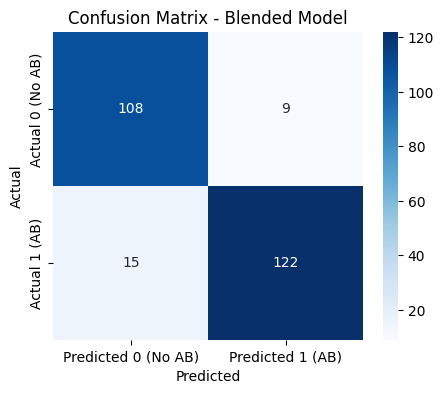

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, final_binary_predictions)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (No AB)', 'Predicted 1 (AB)'],
            yticklabels=['Actual 0 (No AB)', 'Actual 1 (AB)'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Blended Model')
plt.show()


blending : # LGBM: 50%, CatBoost: 30%, XGBoost: 20%

Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002124 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


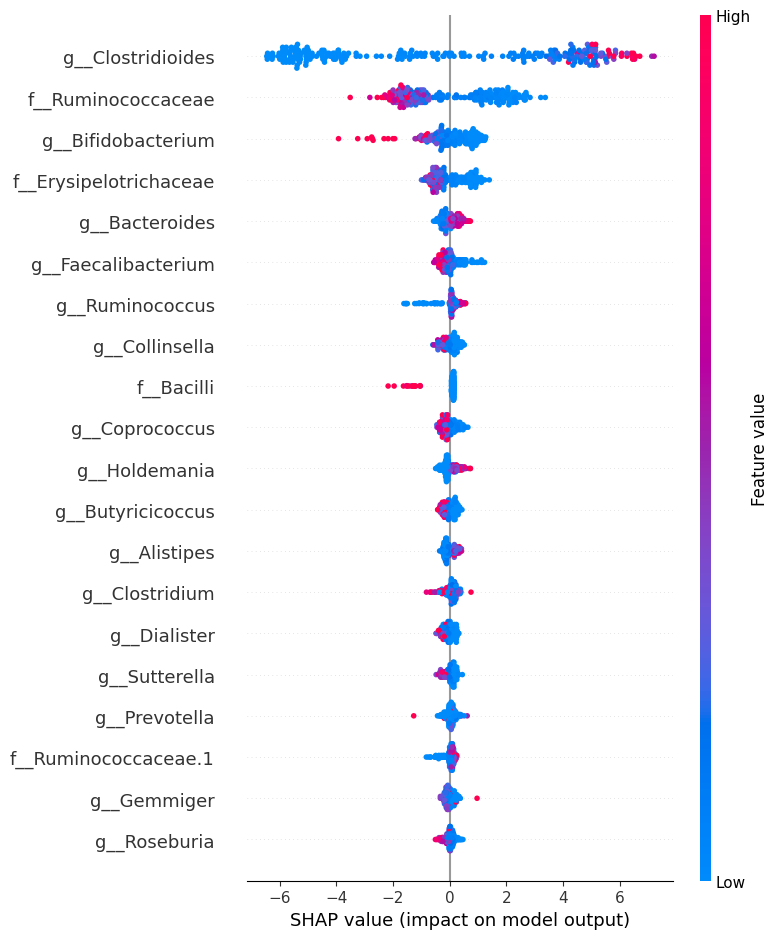

Training catboost...
Performing SHAP analysis for catboost...


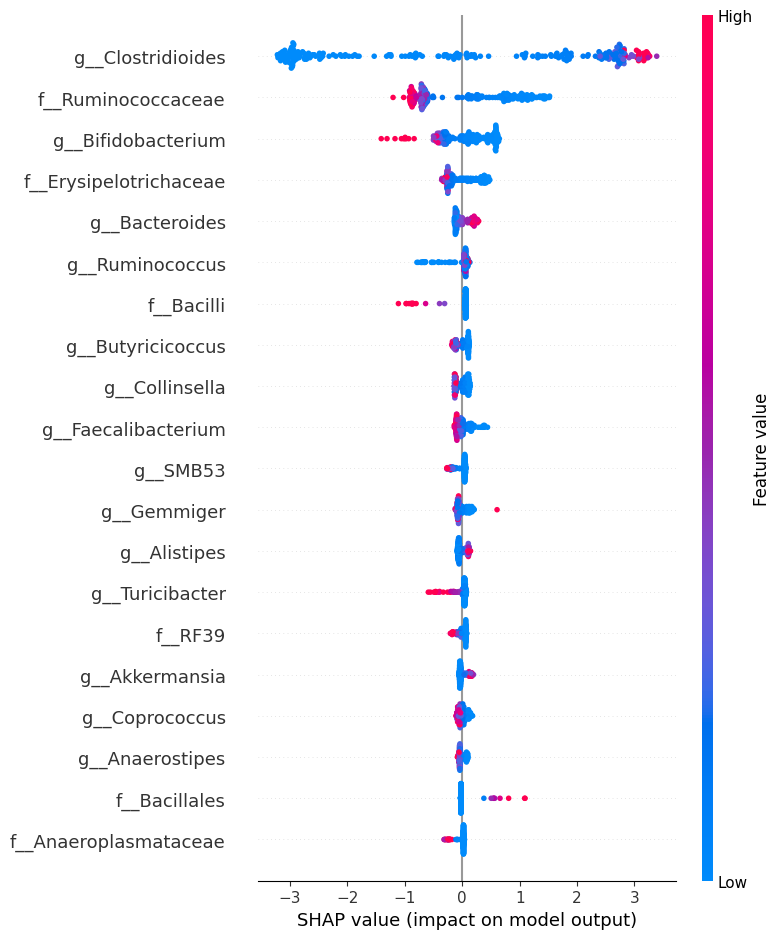

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:39:41] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:39:42] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:39:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:39:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [06:39:44] WARNING: /w

Performing SHAP analysis for xgboost...


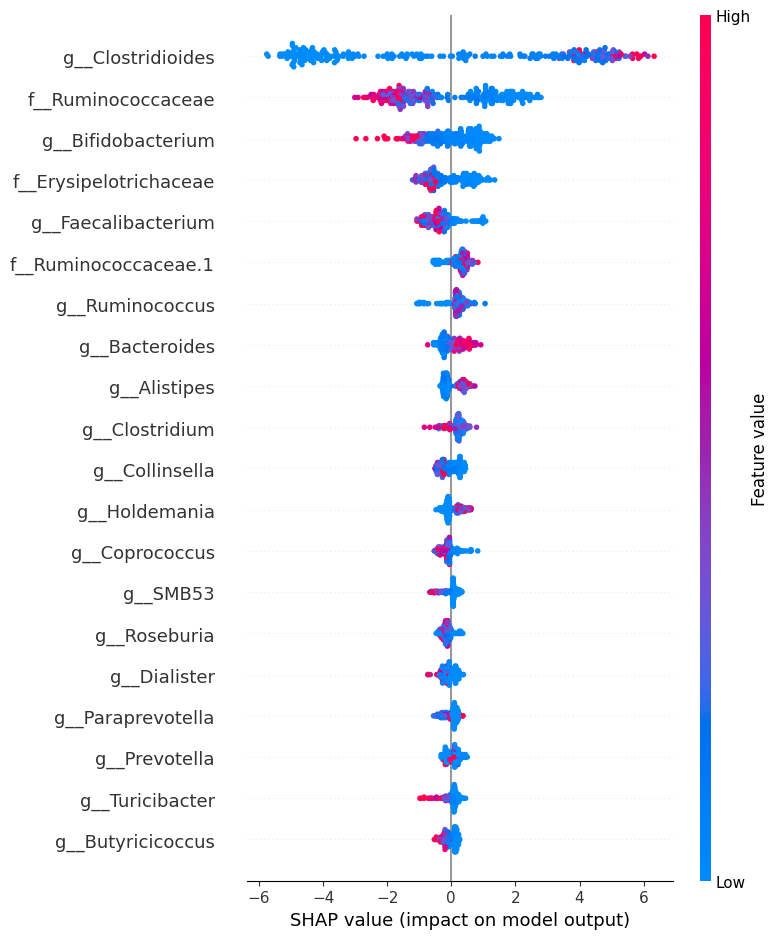

Final AUC of the blended model: 0.9745

Blended Model Performance Metrics:
Precision: 0.931
Recall (Sensitivity): 0.891
Specificity: 0.923
F1 Score: 0.910
Accuracy: 0.906
AUC: 0.975
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

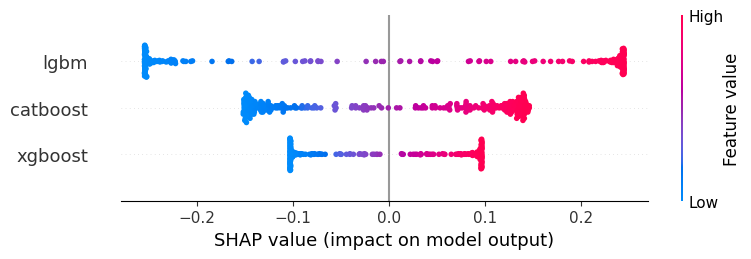

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('/content/final_input_org.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.5, 0.3, 0.2]  # LGBM: 50%, CatBoost: 30%, XGBoost: 20%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001940 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13079
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


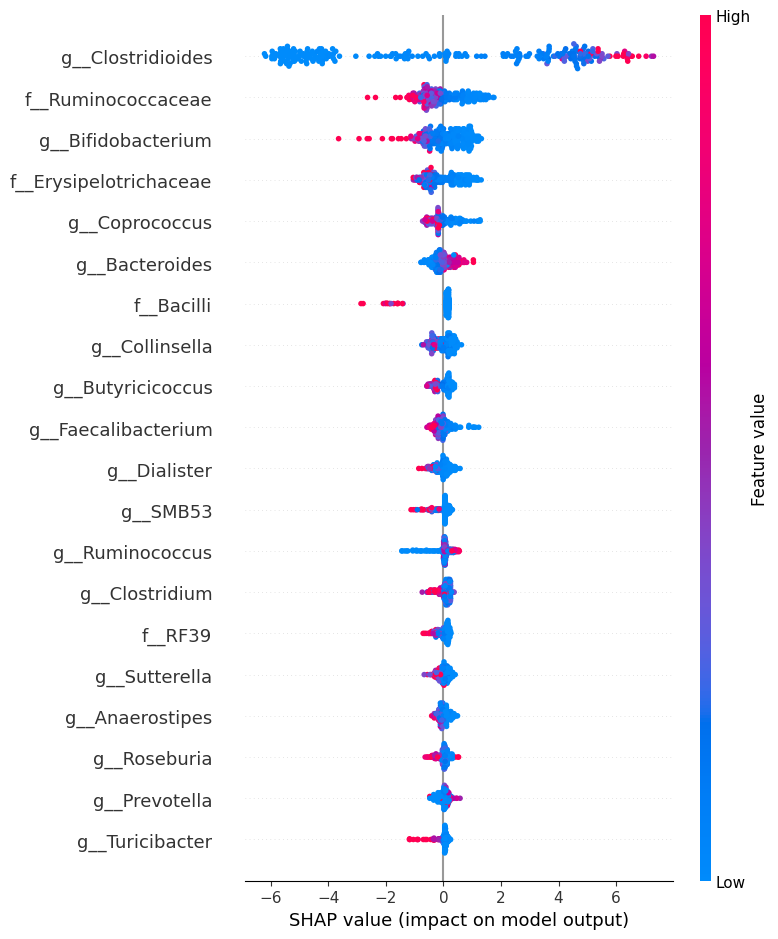

Training catboost...
Performing SHAP analysis for catboost...


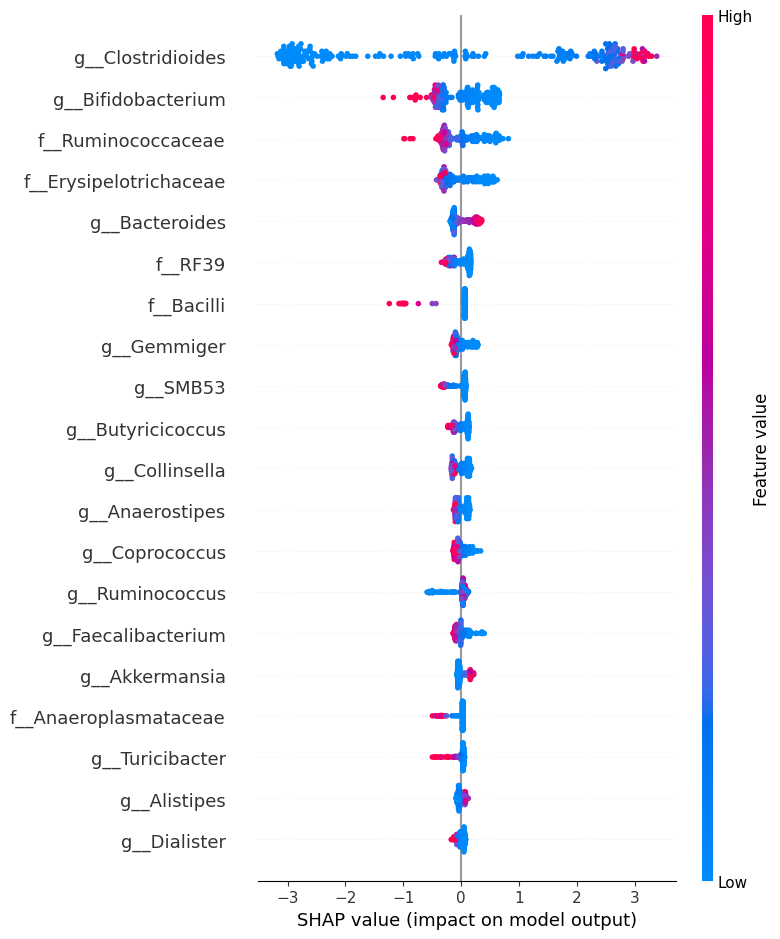

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:58:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:58:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:58:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:58:22] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [09:58:23] WARNING: /w

Performing SHAP analysis for xgboost...


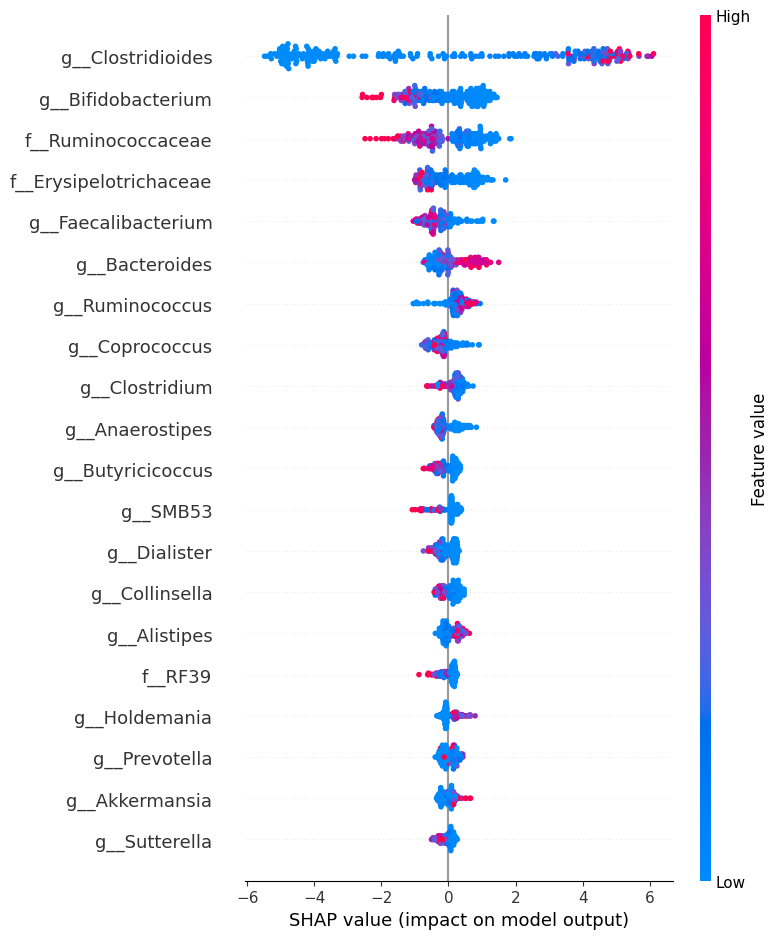

Final AUC of the blended model: 0.9669

Blended Model Performance Metrics:
Precision: 0.912
Recall (Sensitivity): 0.905
Specificity: 0.897
F1 Score: 0.908
Accuracy: 0.902
AUC: 0.967
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

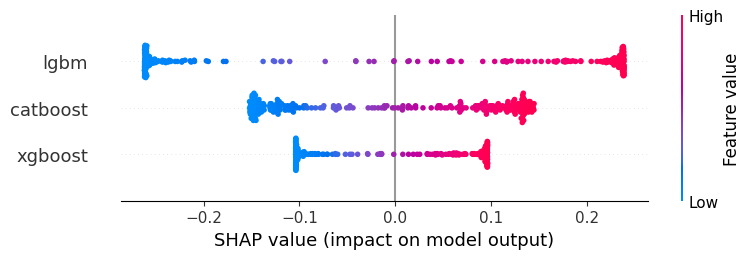

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('/content/final_input_org_rumin.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.5, 0.3, 0.2]  # LGBM: 50%, CatBoost: 30%, XGBoost: 20%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Blending :# LGBM: 50%, CatBoost: 20%, XGBoost: 30%

In [ ]:
print("Original Model Accuracy:", accuracy_score(y_test, model.predict(X_test)))
print("Flipped Label Model Accuracy:", accuracy_score(1 - y_test, model.predict(X_test)))


Original Model Accuracy: 0.8818897637795275
Flipped Label Model Accuracy: 0.11811023622047244


Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001872 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13079
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


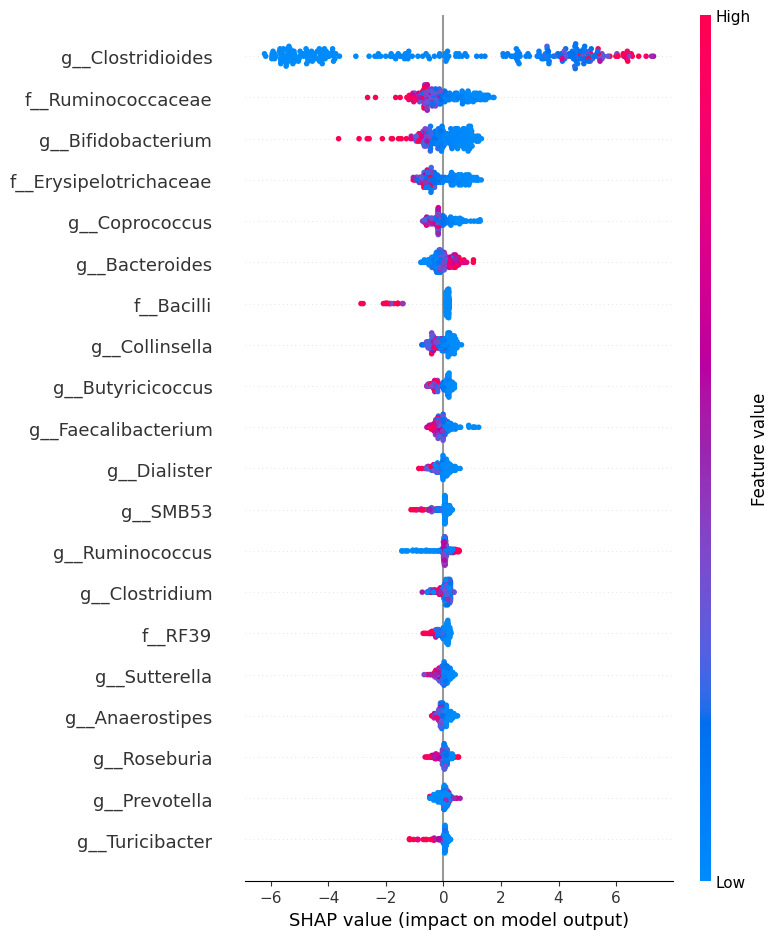

Training catboost...
Performing SHAP analysis for catboost...


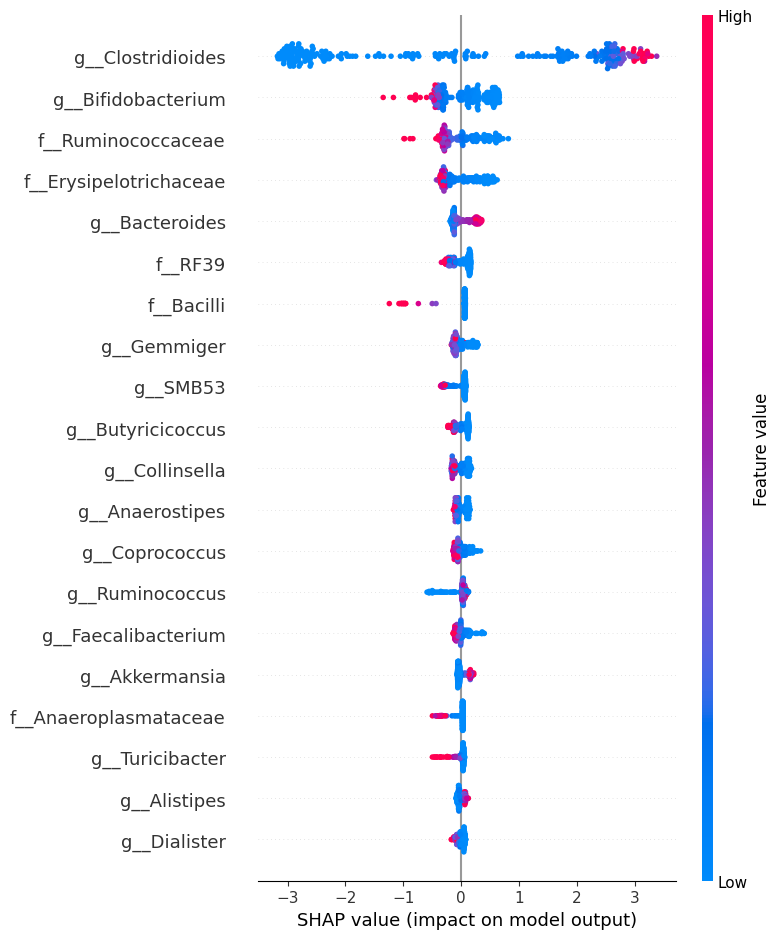

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:15] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:18] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:23] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:07:25] WARNING: /w

Performing SHAP analysis for xgboost...


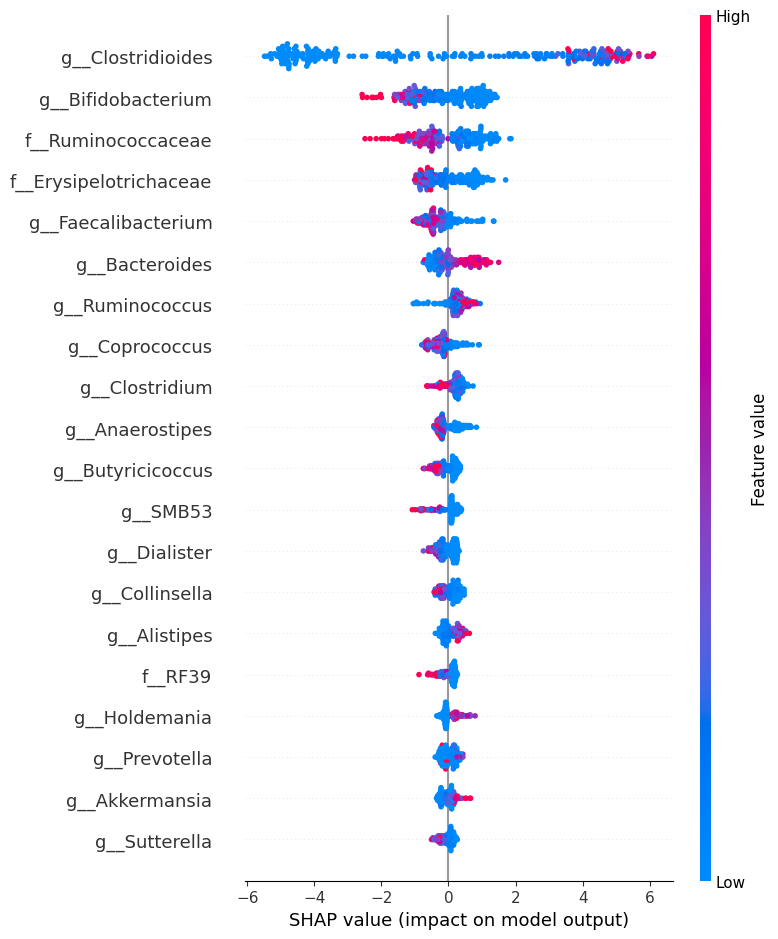

Final AUC of the blended model: 0.9668

Blended Model Performance Metrics:
Precision: 0.912
Recall (Sensitivity): 0.905
Specificity: 0.897
F1 Score: 0.908
Accuracy: 0.902
AUC: 0.967
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

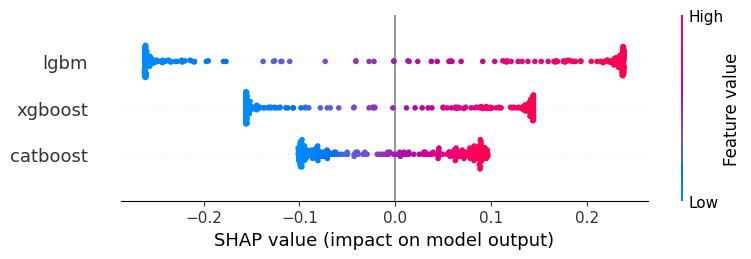

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('/content/final_input_org_rumin.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.5, 0.2, 0.3]  # LGBM: 50%, CatBoost: 20%, XGBoost: 30%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001851 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13079
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 163
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:544: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


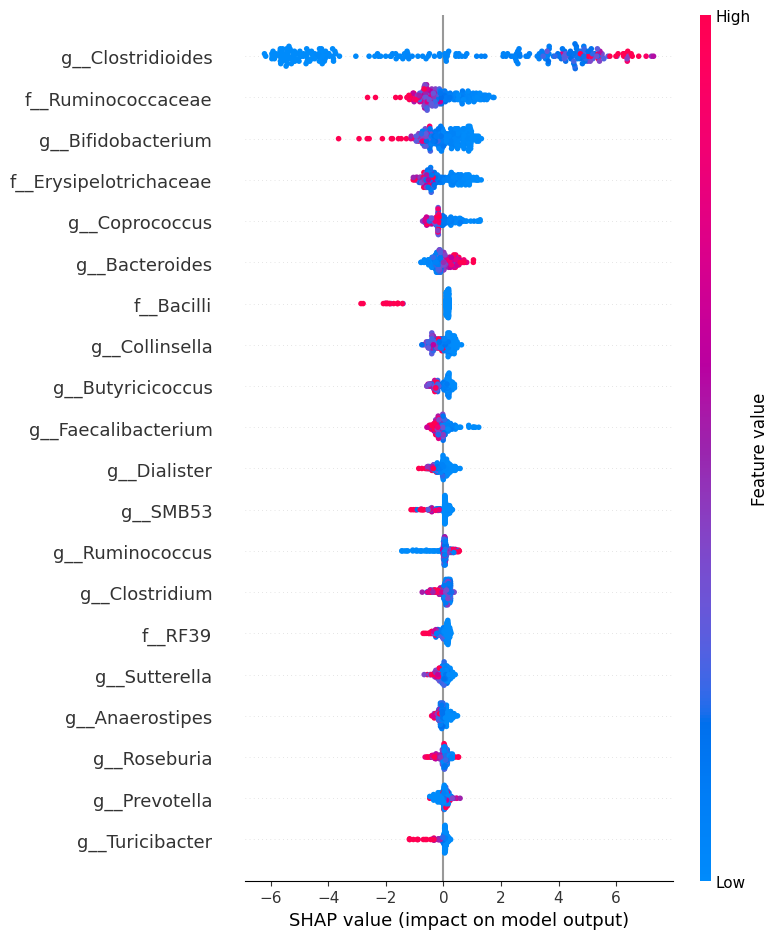

Training catboost...
Performing SHAP analysis for catboost...


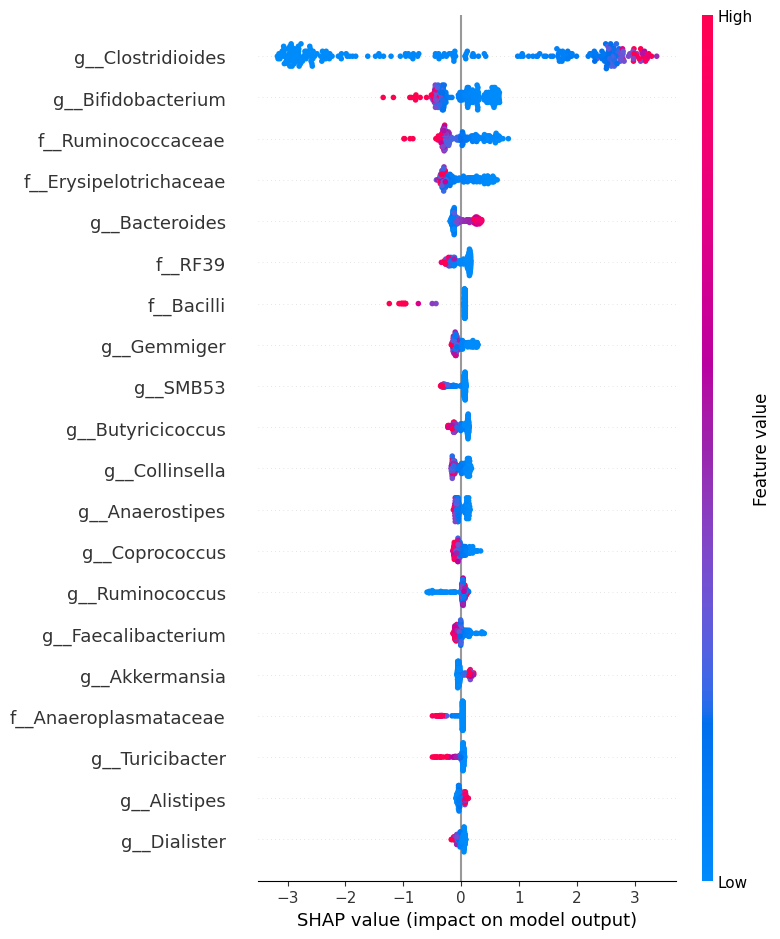

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:10:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:10:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:10:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:10:12] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [10:10:13] WARNING: /w

Performing SHAP analysis for xgboost...


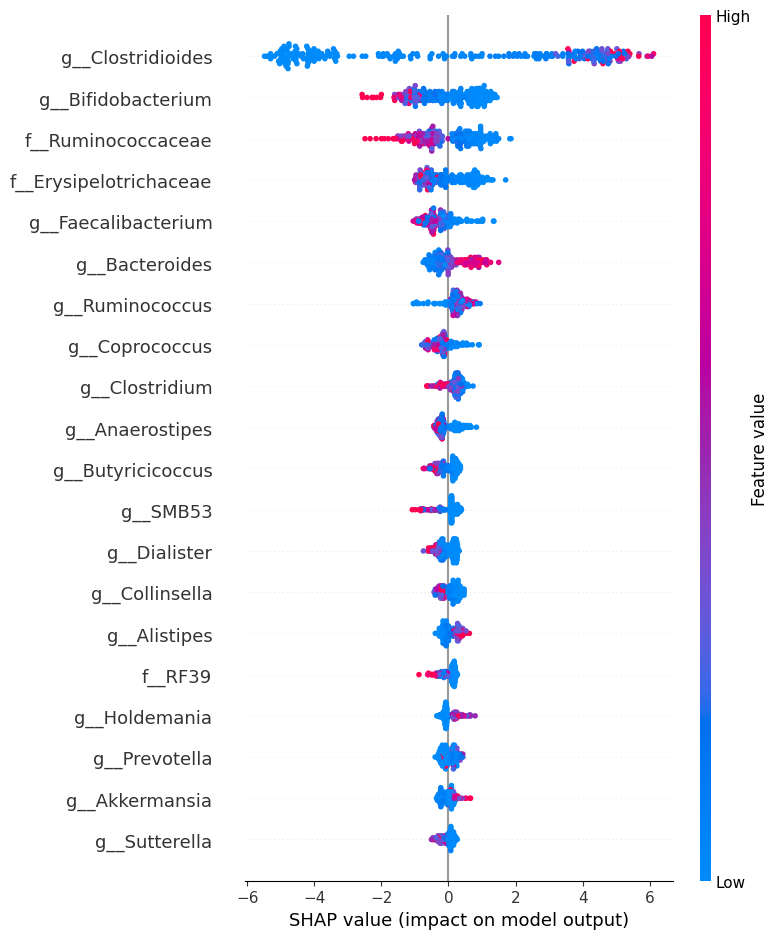

Final AUC of the blended model: 0.9671

Blended Model Performance Metrics:
Precision: 0.912
Recall (Sensitivity): 0.905
Specificity: 0.897
F1 Score: 0.908
Accuracy: 0.902
AUC: 0.967
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

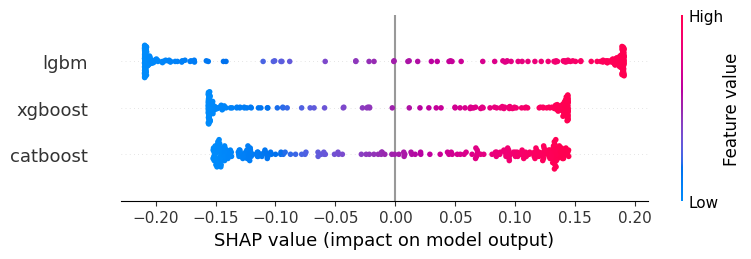

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('/content/final_input_org_rumin.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.4, 0.3, 0.3]  # LGBM: 40%, CatBoost: 30%, XGBoost: 30%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Blending :  # LGBM: 40%, CatBoost: 30%, XGBoost: 30%

Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002630 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


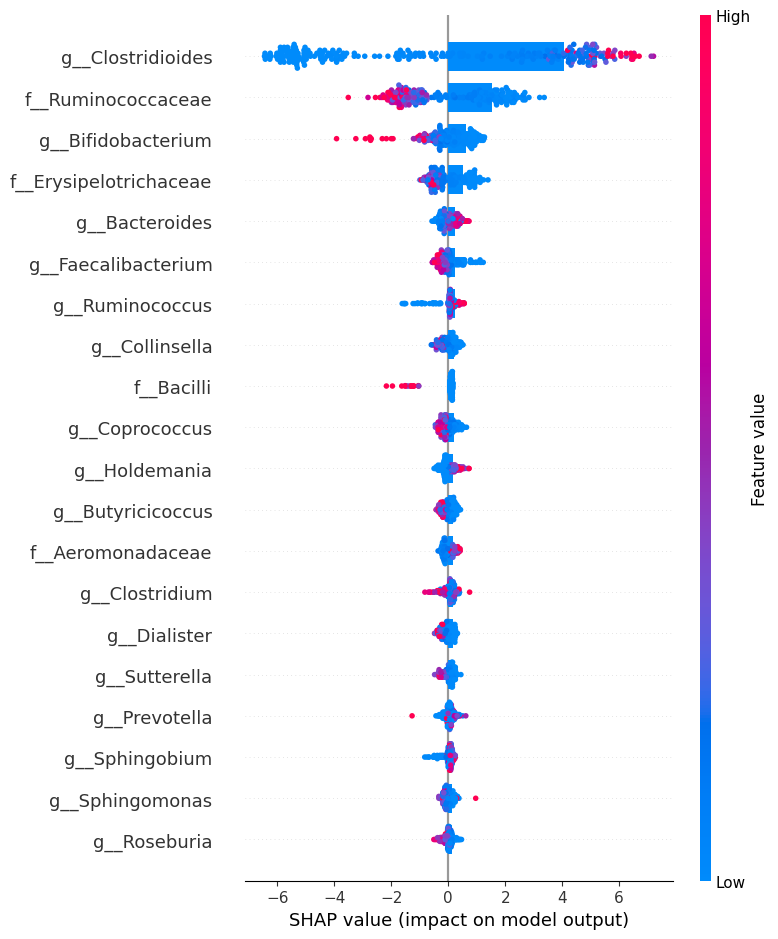

Training catboost...
Performing SHAP analysis for catboost...


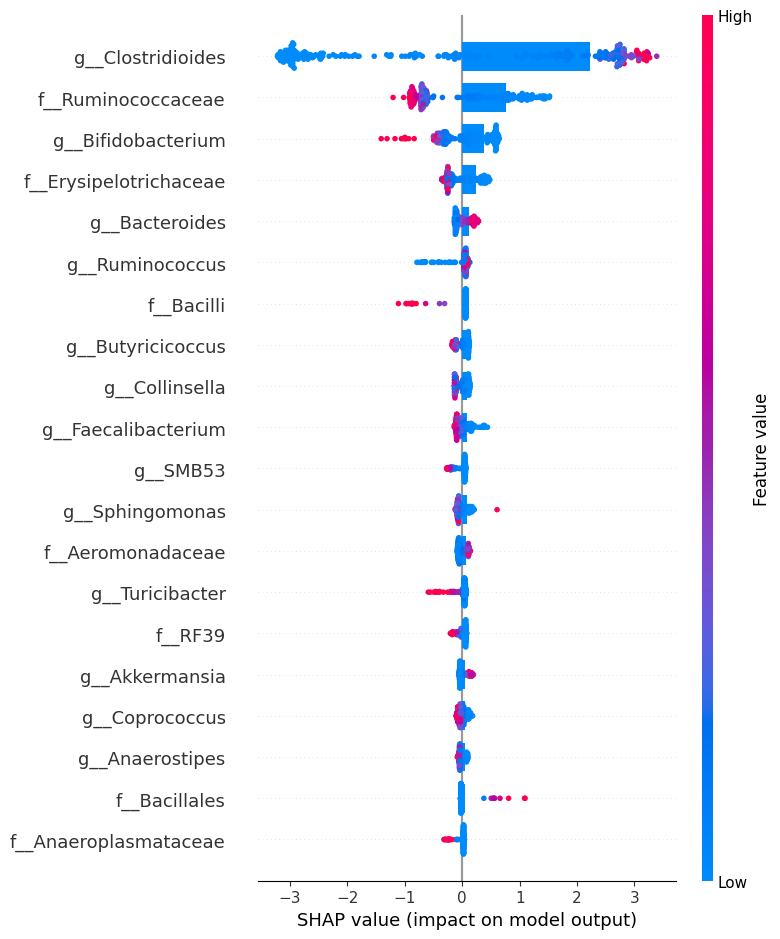

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:58:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:58:25] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:58:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:58:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:58:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Performing SHAP analysis for xgboost...


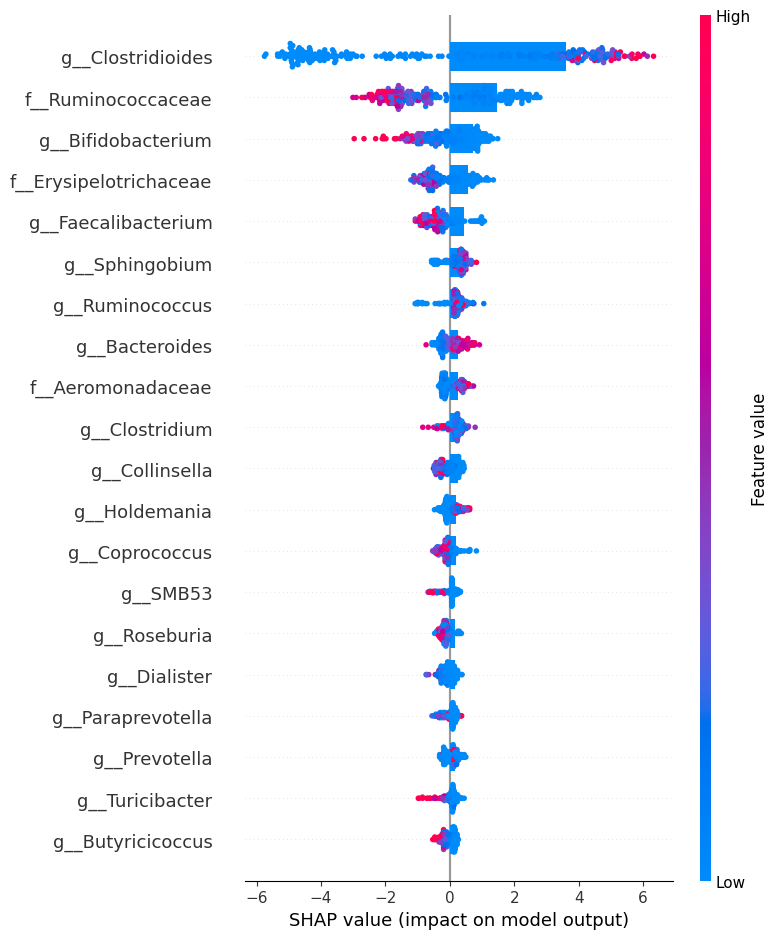

Final AUC of the blended model: 0.9742

Blended Model Performance Metrics:
Precision: 0.924
Recall (Sensitivity): 0.883
Specificity: 0.915
F1 Score: 0.903
Accuracy: 0.898
AUC: 0.974
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

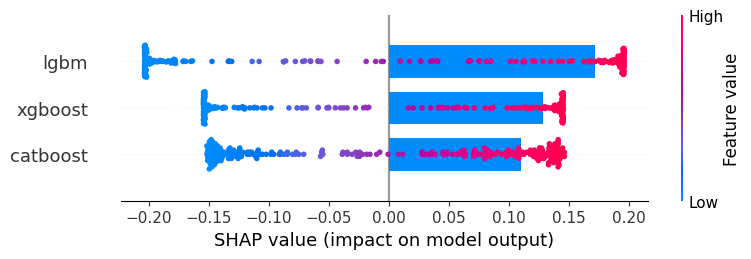

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('final_input.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.4, 0.3, 0.3]  # LGBM: 40%, CatBoost: 30%, XGBoost: 30%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Blending # LGBM: 40%, CatBoost: 40%, XGBoost: 20%

Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001475 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


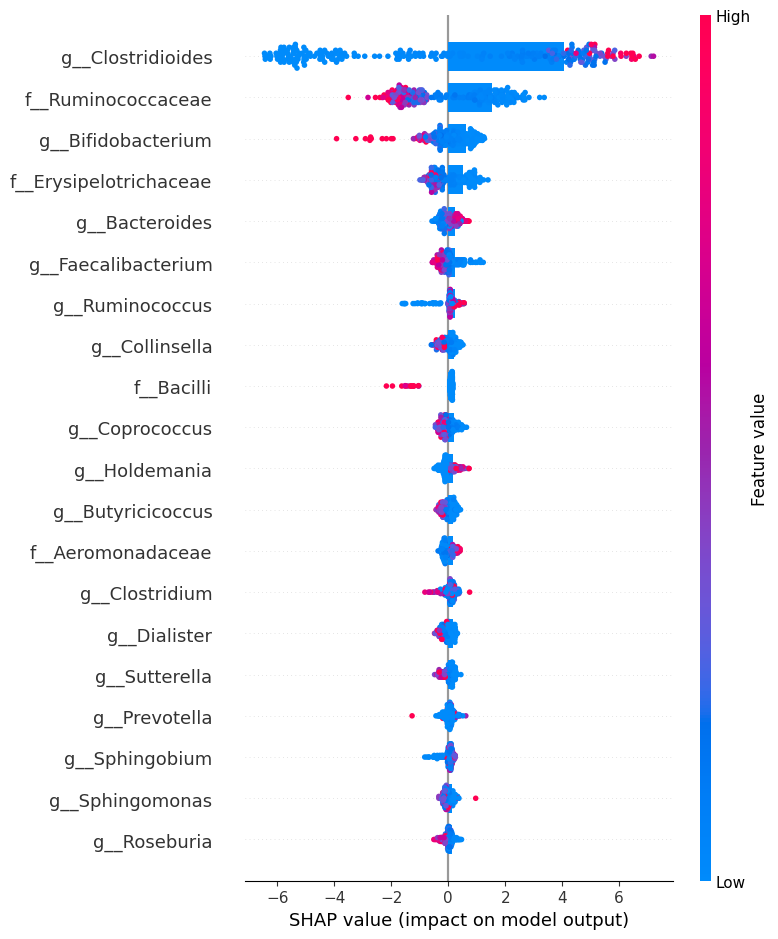

Training catboost...
Performing SHAP analysis for catboost...


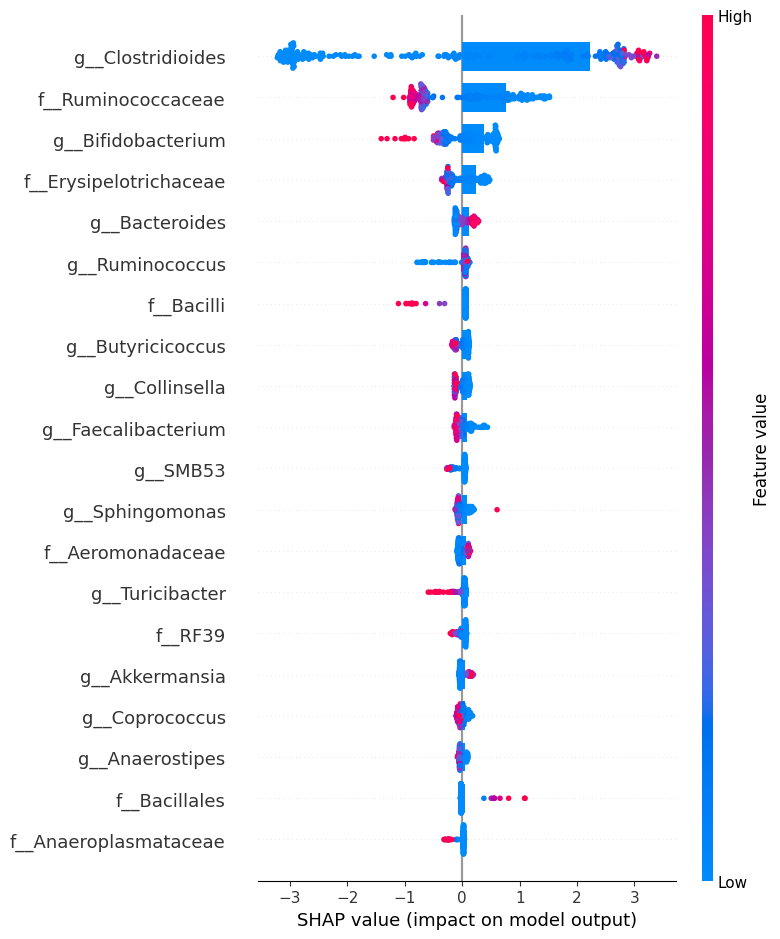

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:03:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:03:27] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:03:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:03:29] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:03:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Performing SHAP analysis for xgboost...


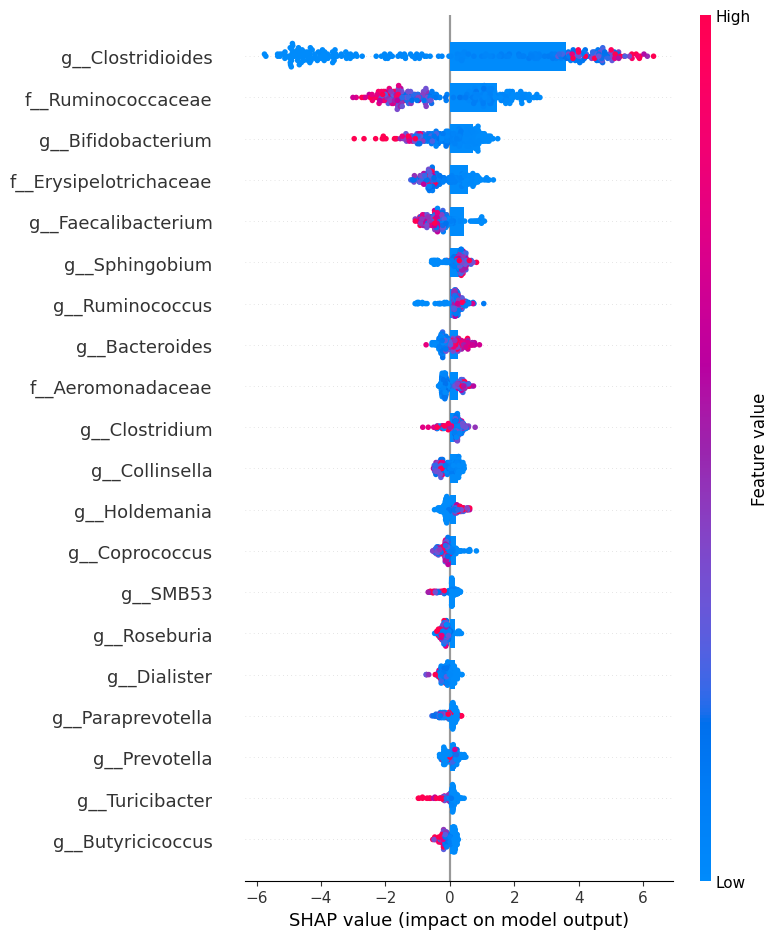

Final AUC of the blended model: 0.9742

Blended Model Performance Metrics:
Precision: 0.931
Recall (Sensitivity): 0.891
Specificity: 0.923
F1 Score: 0.910
Accuracy: 0.906
AUC: 0.974
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

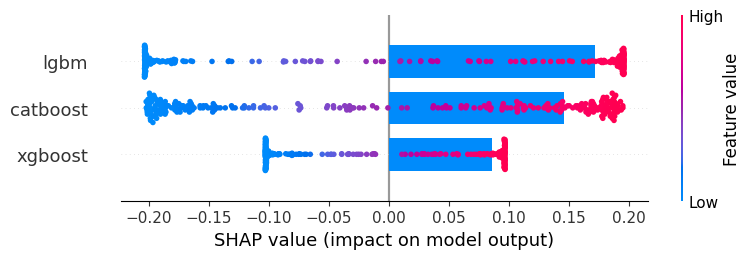

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('final_input.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.4, 0.4, 0.2]  # LGBM: 40%, CatBoost: 40%, XGBoost: 20%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Blending :# LGBM: 40%, CatBoost: 20%, XGBoost: 40%

Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001907 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


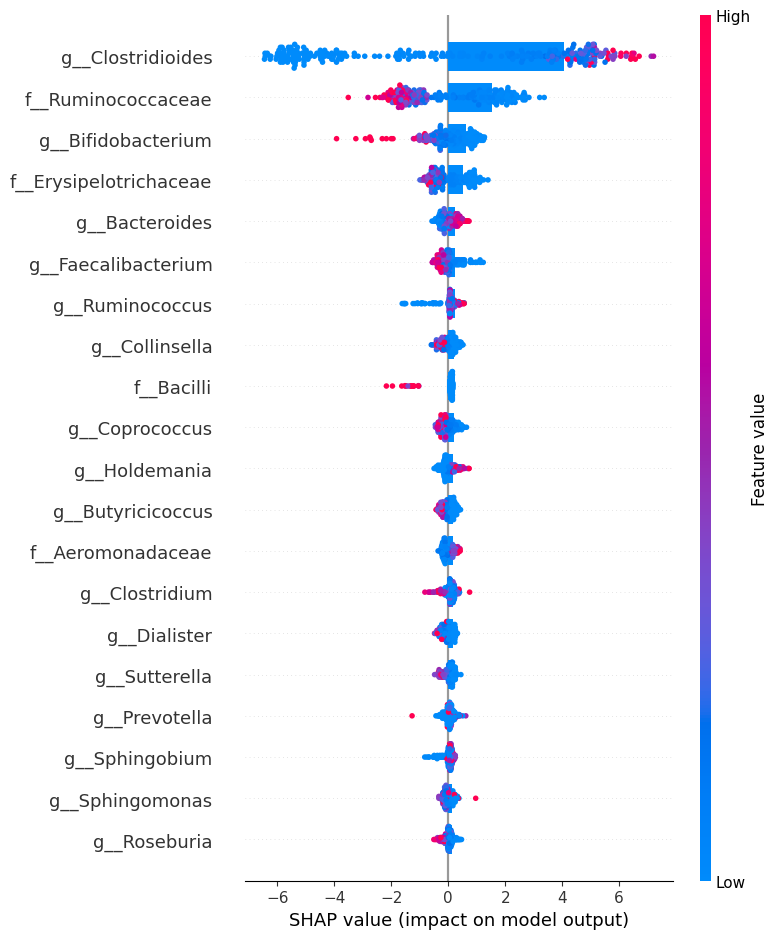

Training catboost...
Performing SHAP analysis for catboost...


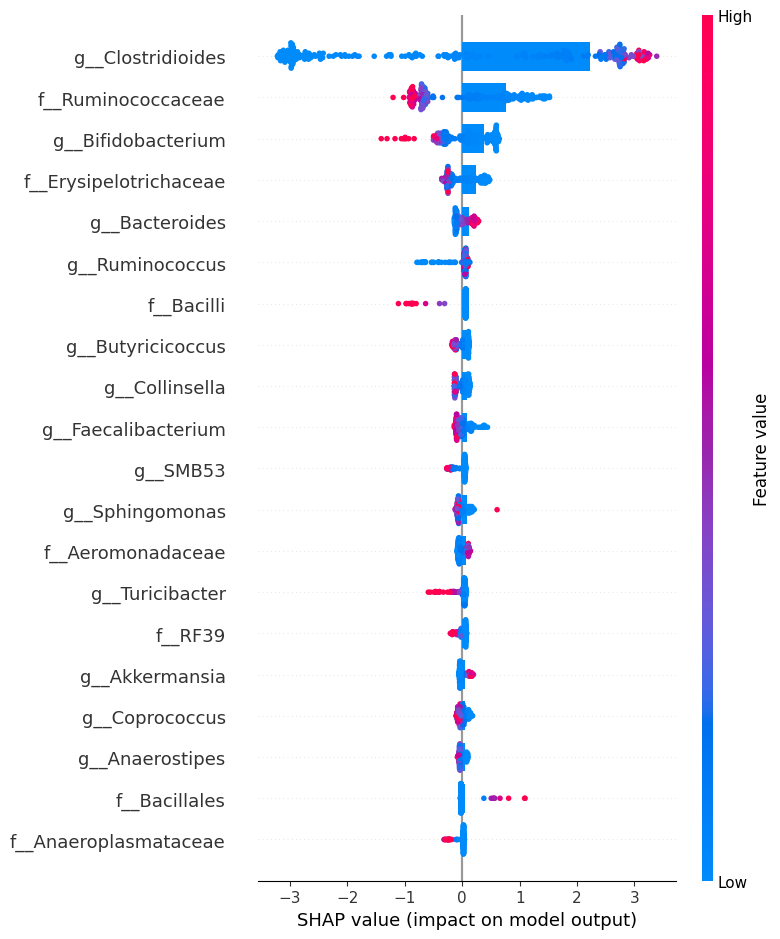

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:06:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:06:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:06:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:06:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:06:46] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Performing SHAP analysis for xgboost...


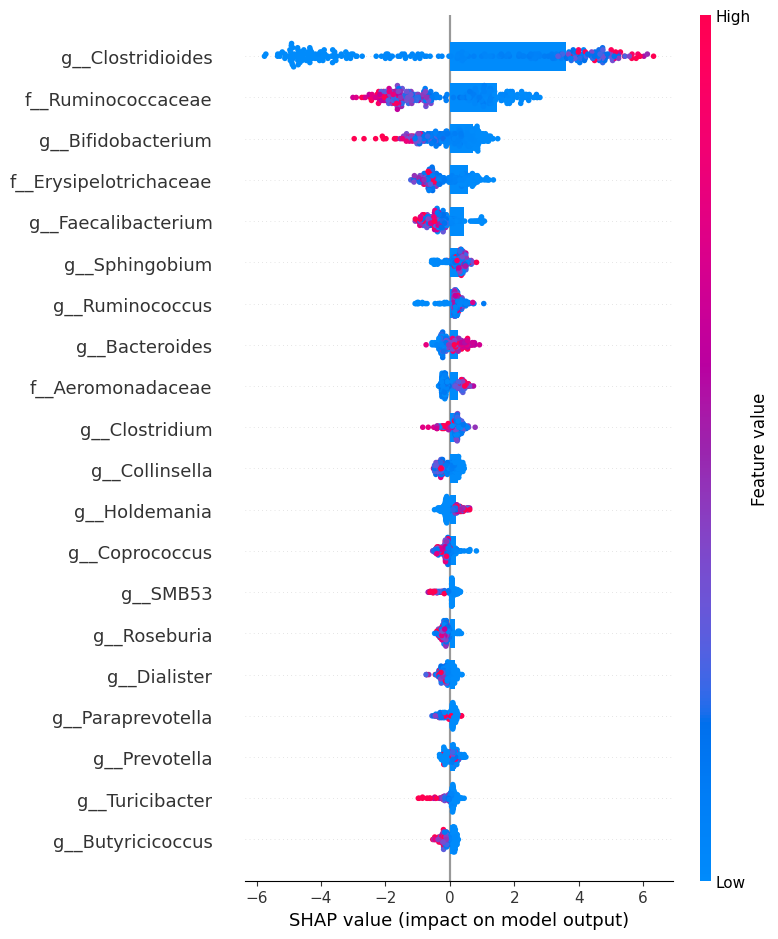

Final AUC of the blended model: 0.9736

Blended Model Performance Metrics:
Precision: 0.916
Recall (Sensitivity): 0.876
Specificity: 0.906
F1 Score: 0.896
Accuracy: 0.890
AUC: 0.974
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

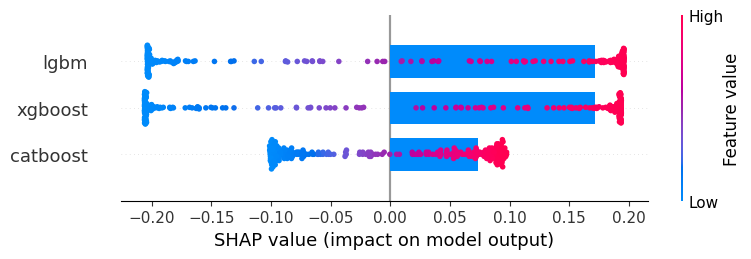

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('final_input.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.4, 0.2, 0.4]  # LGBM: 40%, CatBoost: 20%, XGBoost: 40%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


DataFrame Shape: (6, 5)
Column Names: Index(['LGBM: 50%, CatBoost: 30%, XGBoost: 20%',
       'LGBM: 50%, CatBoost: 20%, XGBoost: 30%',
       'LGBM: 40%, CatBoost: 30%, XGBoost: 30%',
       'LGBM: 40%, CatBoost: 20%, XGBoost: 40%',
       'LGBM: 40%, CatBoost: 40%, XGBoost: 20%'],
      dtype='object')


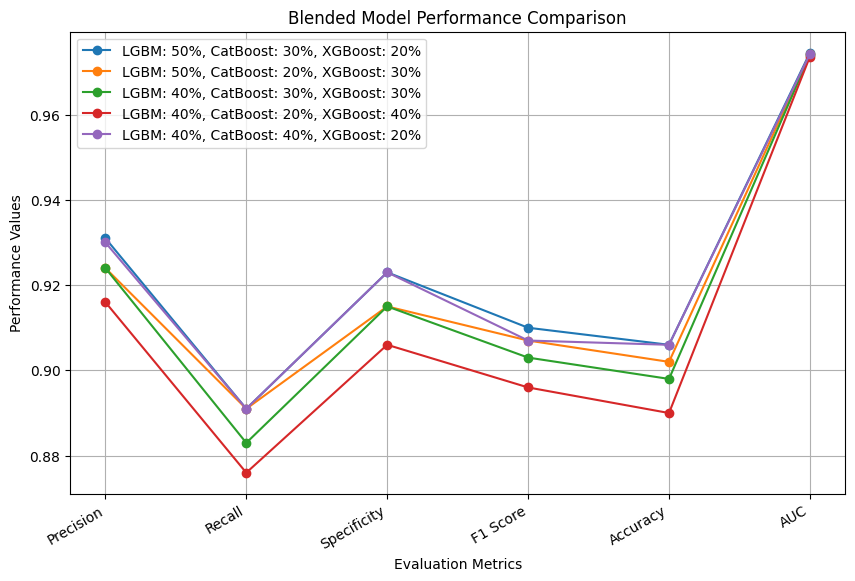

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Data
metrics = ["Precision", "Recall", "Specificity", "F1 Score", "Accuracy", "AUC"]
blending_ratios = [
    "LGBM: 50%, CatBoost: 30%, XGBoost: 20%",
    "LGBM: 50%, CatBoost: 20%, XGBoost: 30%",
    "LGBM: 40%, CatBoost: 30%, XGBoost: 30%",
    "LGBM: 40%, CatBoost: 20%, XGBoost: 40%",
    "LGBM: 40%, CatBoost: 40%, XGBoost: 20%"
]

values = np.array([
    [0.931, 0.891, 0.923, 0.910, 0.906, 0.9745],
    [0.924, 0.891, 0.915, 0.907, 0.902, 0.9742],
    [0.924, 0.883, 0.915, 0.903, 0.898, 0.9740],
    [0.916, 0.876, 0.906, 0.896, 0.890, 0.9736],
    [0.930, 0.891, 0.923, 0.907, 0.906, 0.9742]  # New blending ratio added
])


# Creating a DataFrame for visualization
df = pd.DataFrame(values.T, columns=blending_ratios, index=metrics)

# Debugging: Print DataFrame to check columns
print("DataFrame Shape:", df.shape)
print("Column Names:", df.columns)

# Plotting
plt.figure(figsize=(10, 6))
for blend in df.columns:
    plt.plot(df.index, df[blend], marker='o', label=blend)

plt.xlabel("Evaluation Metrics")
plt.ylabel("Performance Values")
plt.title("Blended Model Performance Comparison")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.grid(True)
plt.show()


Training lgbm...
[LightGBM] [Info] Number of positive: 389, number of negative: 423
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001812 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.479064 -> initscore=-0.083793
[LightGBM] [Info] Start training from score -0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


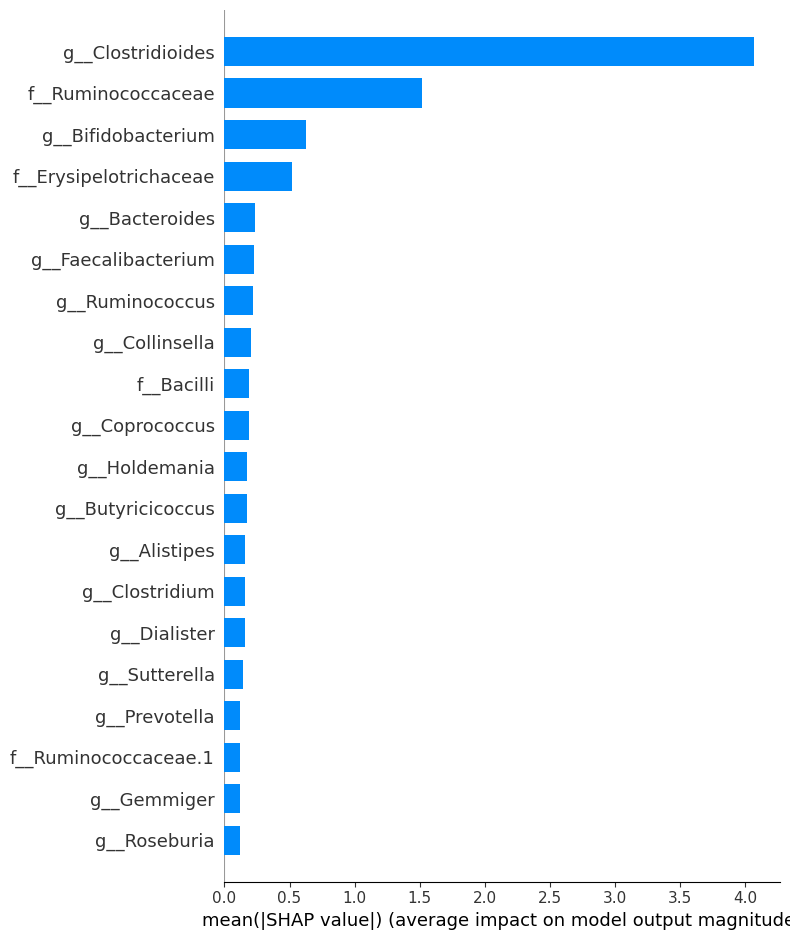

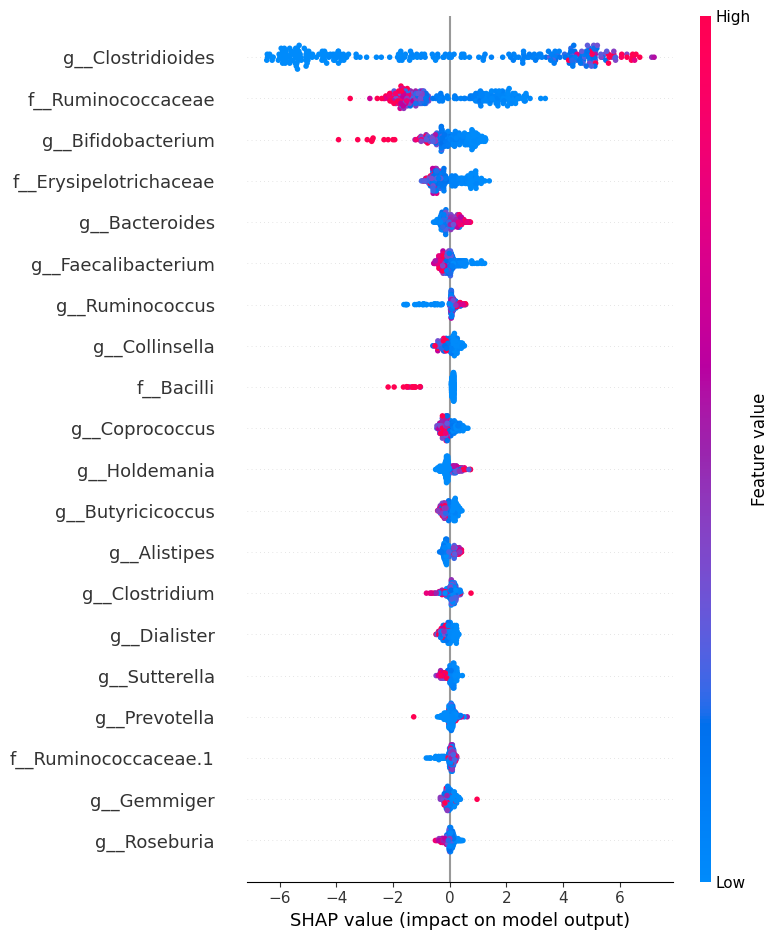

Training catboost...
Performing SHAP analysis for catboost (Class 1)...


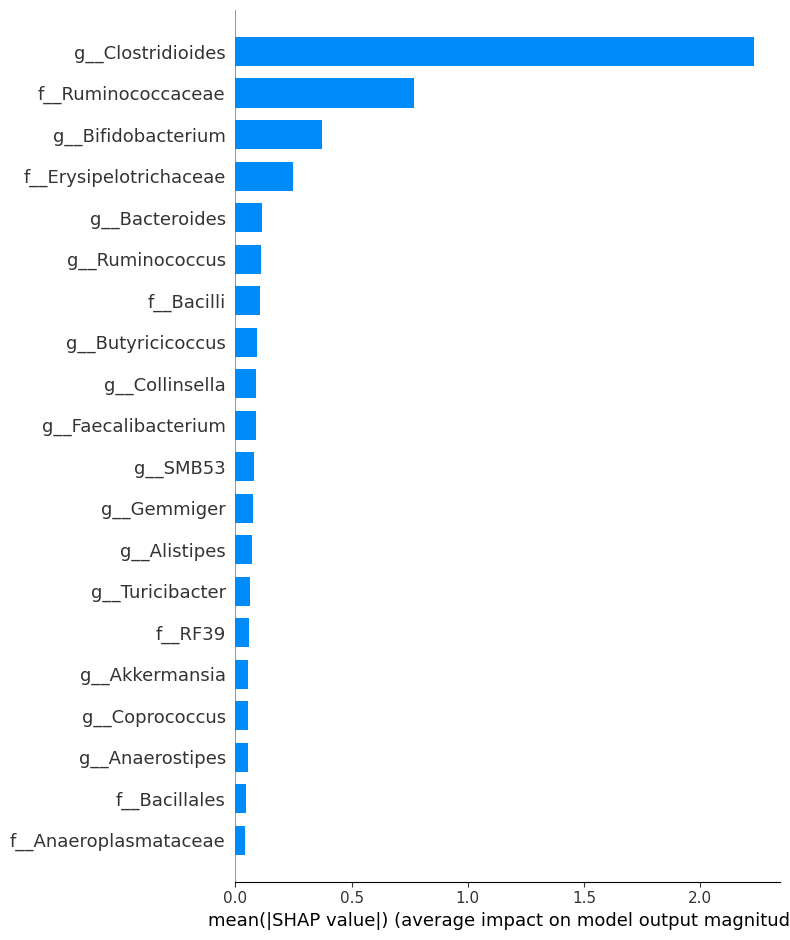

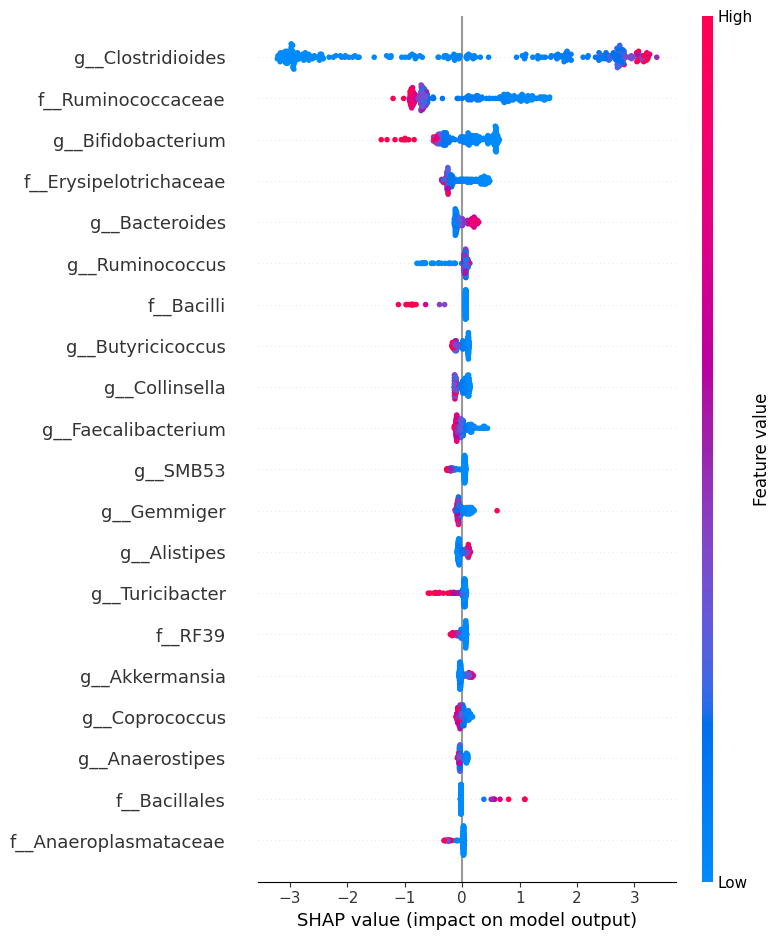

Training xgboost...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:59:00] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:59:01] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:59:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:59:03] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:59:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Performing SHAP analysis for xgboost (Class 1)...


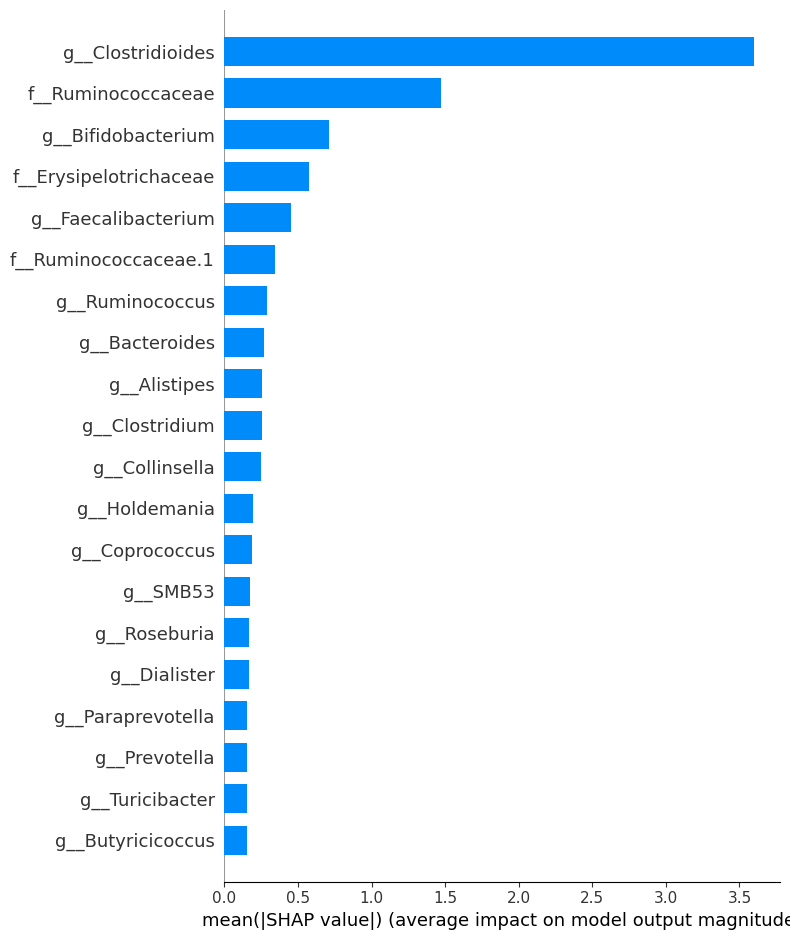

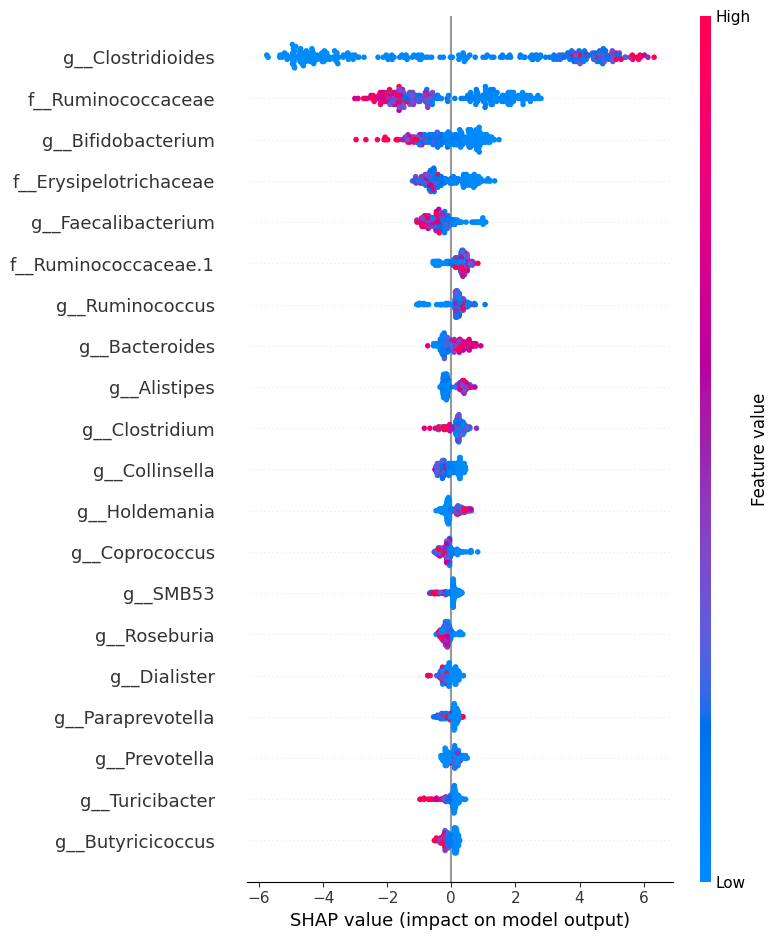

Final AUC of the blended model: 0.9745

Blended Model Performance Metrics:
Precision: 0.931
Recall (Sensitivity): 0.891
Specificity: 0.923
F1 Score: 0.910
Accuracy: 0.906
AUC: 0.974
Performing SHAP analysis for the blended model...


  0%|          | 0/254 [00:00<?, ?it/s]

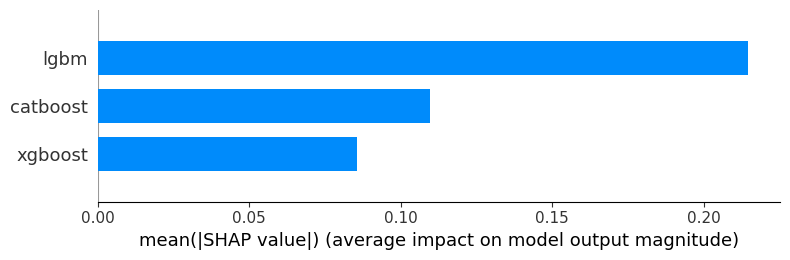

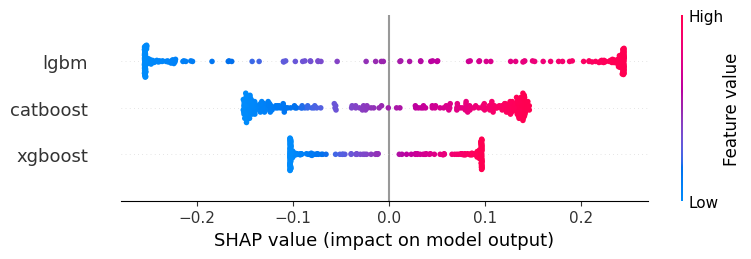

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('final_input_org.csv')
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]  # Prob for class 1
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]  # Prob for class 1

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model (Class 1)
    print(f"Performing SHAP analysis for {name} (Class 1)...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):  # If multiple classes, take class 1
        shap_values = shap_values[1]

    # SHAP Summary Plot for Class 1
    shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.5, 0.3, 0.2]  # LGBM: 50%, CatBoost: 30%, XGBoost: 20%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model: {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics:")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


Training lgbm with flipped labels...
[LightGBM] [Info] Number of positive: 423, number of negative: 389
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13334
[LightGBM] [Info] Number of data points in the train set: 812, number of used features: 164
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.520936 -> initscore=0.083793
[LightGBM] [Info] Start training from score 0.083793
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.11/dist-packages/shap/explainers/_tree.py:448: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn('LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray')


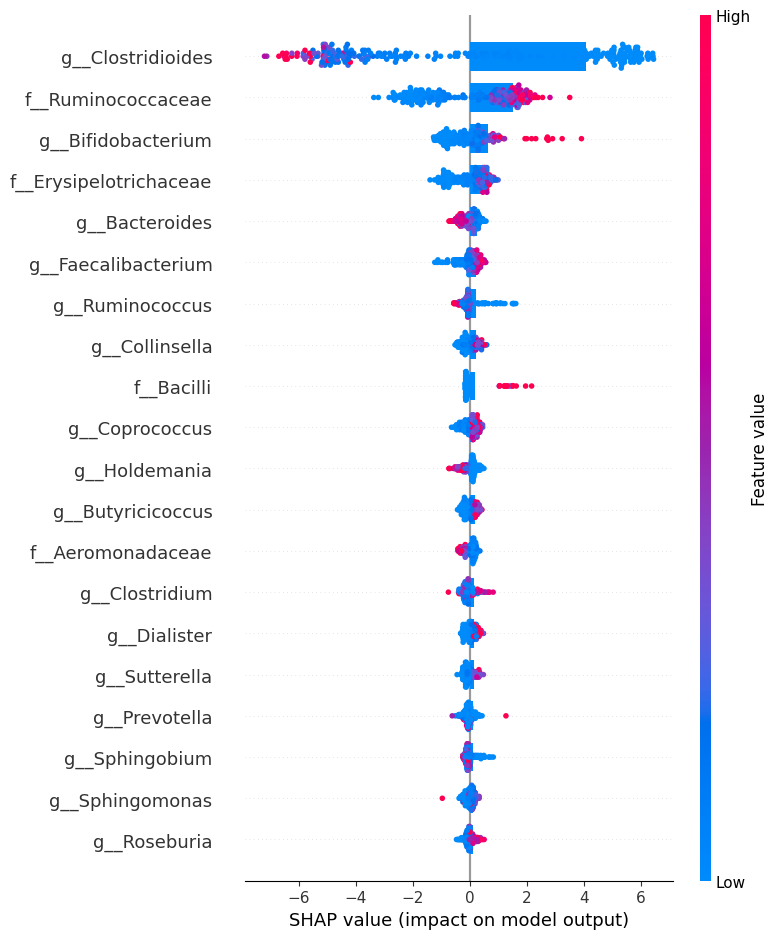

Training catboost with flipped labels...
Performing SHAP analysis for catboost (Flipped Labels)...


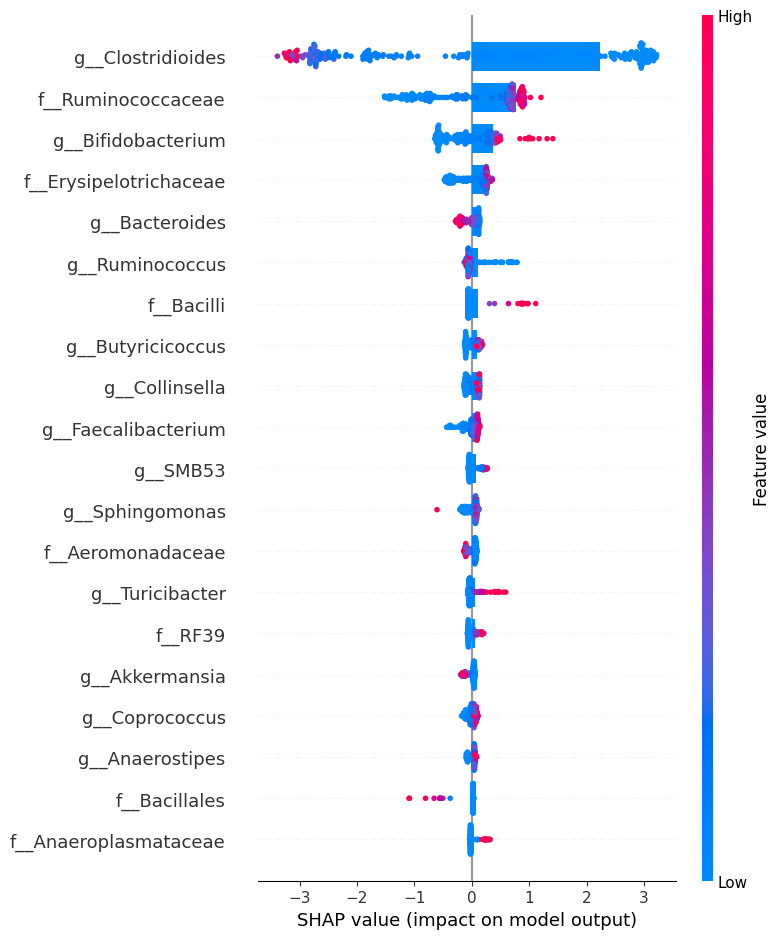

Training xgboost with flipped labels...


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:10:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:10:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:10:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:10:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:10:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Performing SHAP analysis for xgboost (Flipped Labels)...


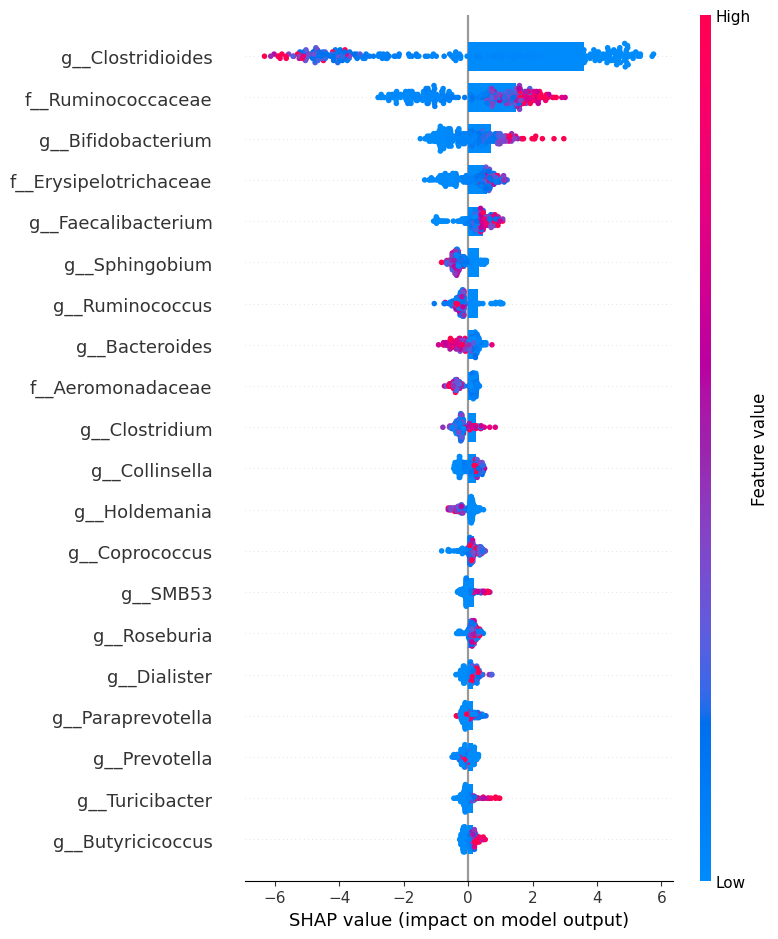

Final AUC of the blended model (Flipped Labels): 0.9742

Blended Model Performance Metrics (Flipped Labels):
Precision: 0.870
Recall (Sensitivity): 0.915
Specificity: 0.883
F1 Score: 0.892
Accuracy: 0.898
AUC: 0.974
Performing SHAP analysis for the blended model (Flipped Labels)...


  0%|          | 0/254 [00:00<?, ?it/s]

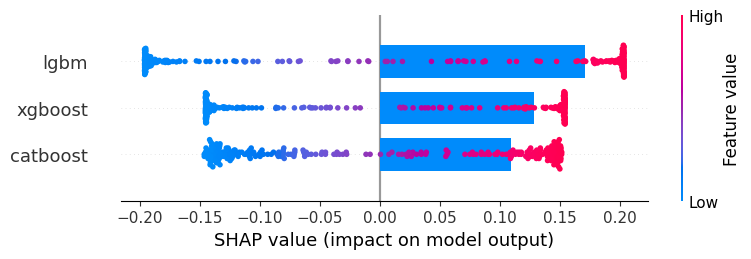

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# Load data
df = pd.read_csv('final_input.csv')

# Flip the target labels (0 ↔ 1)
df['AB_used'] = 1 - df['AB_used']  # Now gut dysbiosis becomes 0 and healthy becomes 1

X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define base models
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Initialize meta-feature storage
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# Generate meta-features
for i, (name, model) in enumerate(base_models.items()):
    print(f"Training {name} with flipped labels...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))  # For averaging test predictions

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    # Average predictions for the test set
    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis for Base Model
    print(f"Performing SHAP analysis for {name} (Flipped Labels)...")
    explainer = shap.TreeExplainer(model)  # TreeExplainer works for tree-based models
    shap_values = explainer.shap_values(X_test)

    # SHAP Summary Plot for the flipped model
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# Blending: Assign weights to the base models
weights = [0.4, 0.3, 0.3]  # LGBM: 40%, CatBoost: 30%, XGBoost: 30%
blended_predictions = np.dot(meta_features_test, weights)

# Evaluate blended predictions
final_auc = roc_auc_score(y_test, blended_predictions)
print(f"Final AUC of the blended model (Flipped Labels): {final_auc:.4f}")

# Convert probabilities to binary predictions
final_binary_predictions = (blended_predictions >= 0.5).astype(int)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

# Metrics Calculation
precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)  # Same as Sensitivity
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

# Print Metrics
print("\nBlended Model Performance Metrics (Flipped Labels):")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")

# Optional: SHAP Analysis for Blended Model
print("Performing SHAP analysis for the blended model (Flipped Labels)...")
explainer_blend = shap.KernelExplainer(lambda x: np.dot(x, weights), meta_features_test)
shap_values_blend = explainer_blend.shap_values(meta_features_test)

# SHAP Summary Plot for Blended Model with Flipped Labels
shap.summary_plot(shap_values_blend, meta_features_test, plot_type="bar", show=False, feature_names=list(base_models.keys()))
shap.summary_plot(shap_values_blend, meta_features_test, feature_names=list(base_models.keys()))


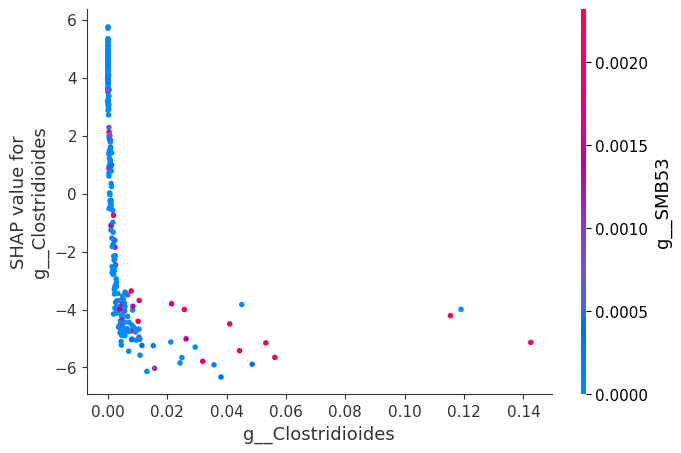

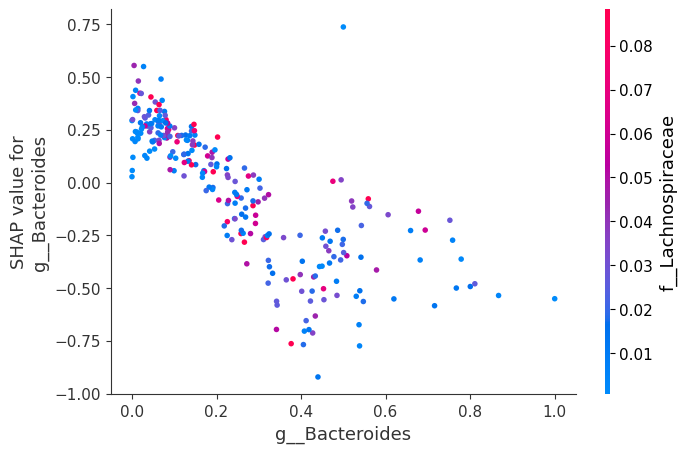

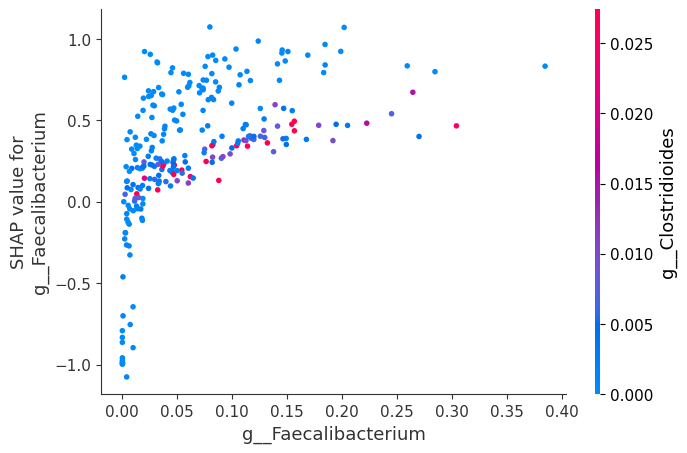

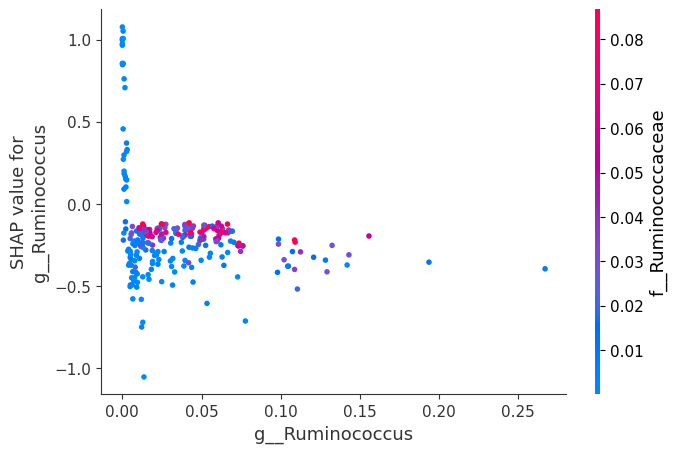

In [ ]:
import shap
import matplotlib.pyplot as plt

# Compute SHAP values again for class 1 (gut dysbiosis)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Ensure we are using SHAP values for Class 1
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# List of key bacteria to analyze
important_features = ["g__Clostridioides", "g__Bacteroides", "g__Faecalibacterium", "g__Ruminococcus"]

# Generate SHAP dependence plots
for feature in important_features:
    shap.dependence_plot(feature, shap_values, X_test)


Final feature count (number of taxa-level features): 437

--- Train/Test Split Summary ---
Total samples: 1270
Training samples: 1016
Test samples: 254

Class counts (training):
AB_used
1    509
0    507
Name: count, dtype: int64

Class counts (test):
AB_used
0    127
1    127
Name: count, dtype: int64

No donor_id column found — cannot check for multiple samples per donor.

--- Cross-validation setup ---
K-Fold CV with K=5, 1 repeat
Fold sizes (validation set sizes): [204, 203, 203, 203, 203]
Typical training size per fold: 812

--- Post-split exclusions ---
None applied after splitting; all exclusions (dropping 'AB_used' and 'sample-name') occurred before splitting.

Training lgbm...
[LightGBM] [Info] Number of positive: 408, number of negative: 404
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


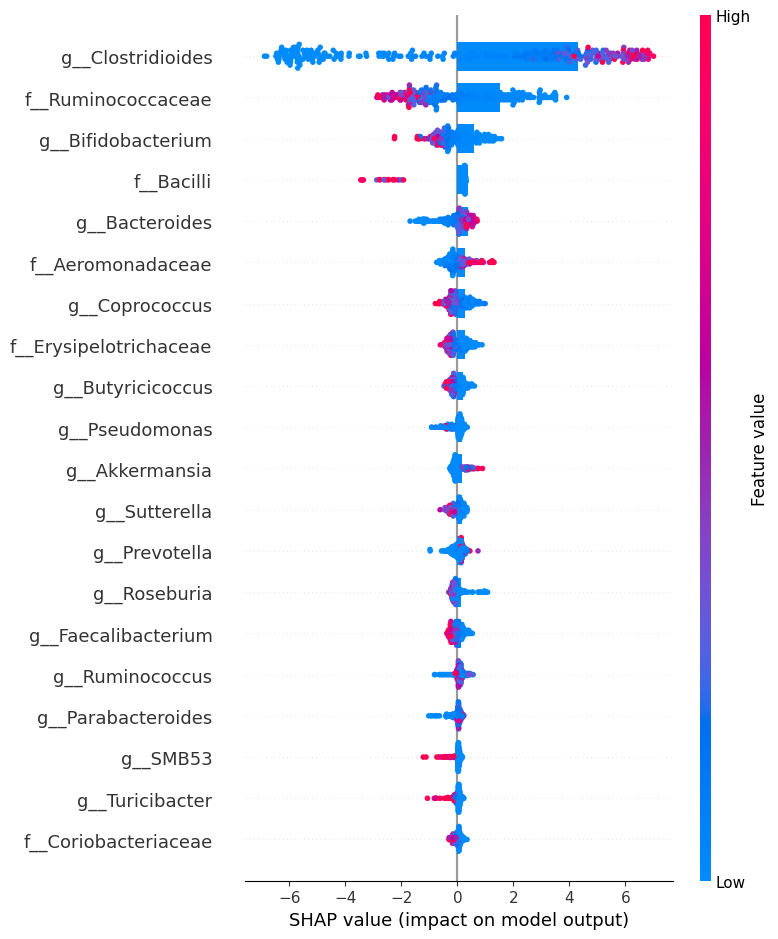


Training catboost...
Performing SHAP analysis for catboost...


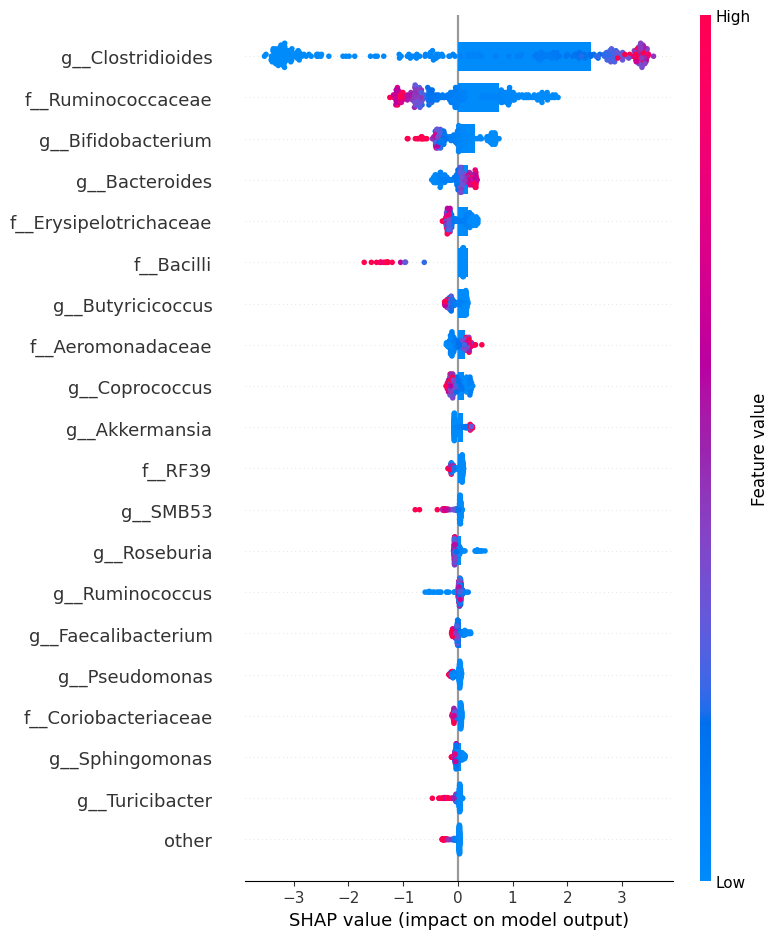


Training xgboost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:42:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:42:01] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:42:02] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:42:03] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [08:42:04] WARNING: /w

Performing SHAP analysis for xgboost...


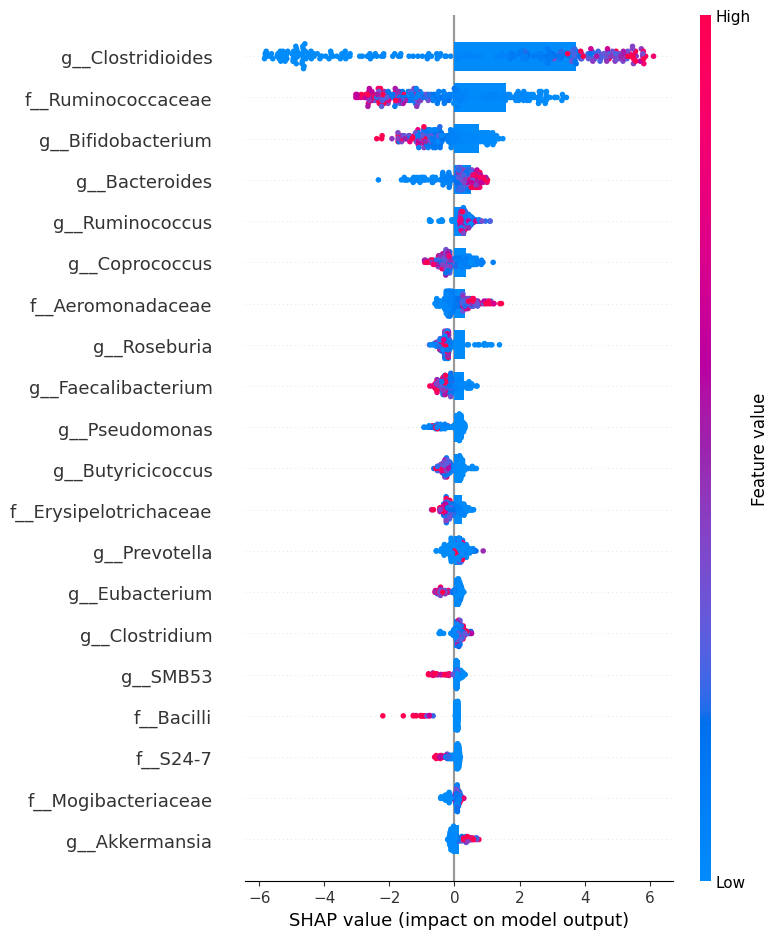


--- Blended Model Performance ---
Precision: 0.869
Recall (Sensitivity): 0.937
Specificity: 0.858
F1 Score: 0.902
Accuracy: 0.898
AUC: 0.959


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
)
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import shap

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv('/content/final_input.csv')

# Features/labels
X = df.drop(['AB_used', 'sample-name'], axis=1)
y = df['AB_used']

# -----------------------------
# Reporting: Feature count
# -----------------------------
print(f"Final feature count (number of taxa-level features): {X.shape[1]}")

# -----------------------------
# Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify ensures class balance
)

print("\n--- Train/Test Split Summary ---")
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

print("\nClass counts (training):")
print(y_train.value_counts())

print("\nClass counts (test):")
print(y_test.value_counts())

# -----------------------------
# Unique donors (if available)
# -----------------------------
if "donor_id" in df.columns:
    unique_donors_total = df["donor_id"].nunique()
    donors_train = df.loc[X_train.index, "donor_id"].nunique()
    donors_test = df.loc[X_test.index, "donor_id"].nunique()
    print("\n--- Donor information ---")
    print(f"Unique donors (total): {unique_donors_total}")
    print(f"Unique donors (train): {donors_train}")
    print(f"Unique donors (test): {donors_test}")
    print("Note: Grouped splitting by donor was NOT applied unless explicitly coded.")
else:
    print("\nNo donor_id column found — cannot check for multiple samples per donor.")

# -----------------------------
# Cross-validation setup
# -----------------------------
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_sizes = [len(val_idx) for _, val_idx in kf.split(X_train)]

print("\n--- Cross-validation setup ---")
print(f"K-Fold CV with K={n_splits}, 1 repeat")
print("Fold sizes (validation set sizes):", fold_sizes)
print(f"Typical training size per fold: {len(X_train) - fold_sizes[0]}")

# -----------------------------
# Post-split exclusions
# -----------------------------
print("\n--- Post-split exclusions ---")
print("None applied after splitting; all exclusions (dropping 'AB_used' and 'sample-name') occurred before splitting.")

# -----------------------------
# Define base models
# -----------------------------
base_models = {
    "lgbm": LGBMClassifier(num_leaves=50, random_state=42),
    "catboost": CatBoostClassifier(iterations=1000, learning_rate=0.01, verbose=0, random_state=42),
    "xgboost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# -----------------------------
# Meta-feature storage
# -----------------------------
meta_features_train = np.zeros((len(X_train), len(base_models)))
meta_features_test = np.zeros((len(X_test), len(base_models)))

# -----------------------------
# Training + Meta-feature generation
# -----------------------------
for i, (name, model) in enumerate(base_models.items()):
    print(f"\nTraining {name}...")
    test_fold_predictions = np.zeros((len(X_test), n_splits))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_meta_train, X_meta_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_meta_train, y_meta_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_meta_train, y_meta_train)
        meta_features_train[val_idx, i] = model.predict_proba(X_meta_val)[:, 1]
        test_fold_predictions[:, fold] = model.predict_proba(X_test)[:, 1]

    meta_features_test[:, i] = test_fold_predictions.mean(axis=1)

    # SHAP Analysis
    print(f"Performing SHAP analysis for {name}...")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, feature_names=X.columns.tolist())
    shap.summary_plot(shap_values, X_test, feature_names=X.columns.tolist())

# -----------------------------
# Blending and Evaluation
# -----------------------------
weights = [0.5, 0.3, 0.2]
blended_predictions = np.dot(meta_features_test, weights)
final_auc = roc_auc_score(y_test, blended_predictions)

final_binary_predictions = (blended_predictions >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, final_binary_predictions).ravel()

precision = precision_score(y_test, final_binary_predictions)
recall = recall_score(y_test, final_binary_predictions)
specificity = tn / (tn + fp)
f1 = f1_score(y_test, final_binary_predictions)
accuracy = accuracy_score(y_test, final_binary_predictions)

print("\n--- Blended Model Performance ---")
print(f"Precision: {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"AUC: {final_auc:.3f}")


In [ ]:
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

# -----------------------------
# Pre-specified threshold
# -----------------------------
threshold = 0.5  # you used >=0.5 already
print(f"\nOperating threshold for precision/recall/F1: {threshold}")

# -----------------------------
# PR-AUC
# -----------------------------
pr_auc = average_precision_score(y_test, blended_predictions)
print(f"PR-AUC: {pr_auc:.3f}")

# -----------------------------
# Calibration (Brier score + ECE)
# -----------------------------
brier = brier_score_loss(y_test, blended_predictions)

# Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    bin_counts, bin_edges = np.histogram(y_prob, bins=n_bins)
    ece = 0.0
    for i in range(len(prob_true)):
        p_true = prob_true[i]
        p_pred = prob_pred[i]
        weight = bin_counts[i] / len(y_true)
        ece += weight * abs(p_true - p_pred)
    return ece

ece = expected_calibration_error(y_test, blended_predictions, n_bins=10)
print(f"Brier score: {brier:.3f}")
print(f"Expected Calibration Error (ECE): {ece:.3f}")

# -----------------------------
# 95% Confidence Intervals via bootstrapping
# -----------------------------
def bootstrap_ci(metric_func, y_true, y_prob, n_boot=1000, alpha=0.05):
    scores = []
    n = len(y_true)
    rng = np.random.RandomState(42)
    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        scores.append(metric_func(y_true[idx], y_prob[idx]))
    lower = np.percentile(scores, 100*alpha/2)
    upper = np.percentile(scores, 100*(1-alpha/2))
    return np.mean(scores), (lower, upper)

# ROC-AUC CI
roc_auc_mean, roc_auc_ci = bootstrap_ci(roc_auc_score, y_test.values, blended_predictions)
# PR-AUC CI
pr_auc_mean, pr_auc_ci = bootstrap_ci(average_precision_score, y_test.values, blended_predictions)
# Brier CI
brier_mean, brier_ci = bootstrap_ci(lambda y, p: brier_score_loss(y, p), y_test.values, blended_predictions)

print("\n--- Metrics with 95% CIs (bootstrap) ---")
print(f"ROC-AUC: {roc_auc_mean:.3f} (95% CI {roc_auc_ci[0]:.3f}-{roc_auc_ci[1]:.3f})")
print(f"PR-AUC: {pr_auc_mean:.3f} (95% CI {pr_auc_ci[0]:.3f}-{pr_auc_ci[1]:.3f})")
print(f"Brier score: {brier_mean:.3f} (95% CI {brier_ci[0]:.3f}-{brier_ci[1]:.3f})")
print(f"ECE (point estimate only): {ece:.3f}")



Operating threshold for precision/recall/F1: 0.5
PR-AUC: 0.957
Brier score: 0.082
Expected Calibration Error (ECE): 0.046

--- Metrics with 95% CIs (bootstrap) ---
ROC-AUC: 0.959 (95% CI 0.936-0.978)
PR-AUC: 0.957 (95% CI 0.931-0.979)
Brier score: 0.083 (95% CI 0.057-0.109)
ECE (point estimate only): 0.046
